# **Exoplanet Habitablity Prediction Exploratory Data Analysis**

In [ ]:
# Importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **Initial Data Preprocessing**

In [ ]:
# loading dataset
df = pd.read_excel('/content/drive/MyDrive/Exoplanet /exoplanet_habitability_data.xlsx')

In [ ]:
# Viewing the first 5 rows of the dataset
df.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,11 Com b,11 Com,1,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-08,2023-09-19
1,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-05-14,2008-01,2014-05-14
2,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-07-23,2011-08,2014-07-23
3,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-04-25,2009-10,2014-05-14
4,11 UMi b,11 UMi,1,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-09-04,2017-03,2018-09-06


In [ ]:
# viewing dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39235 entries, 0 to 39234
Data columns (total 92 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pl_name          39235 non-null  object        
 1   hostname         39235 non-null  object        
 2   default_flag     39235 non-null  int64         
 3   sy_snum          39235 non-null  int64         
 4   sy_pnum          39235 non-null  int64         
 5   discoverymethod  39235 non-null  object        
 6   disc_year        39235 non-null  int64         
 7   disc_facility    39235 non-null  object        
 8   soltype          39235 non-null  object        
 9   pl_controv_flag  39235 non-null  int64         
 10  pl_refname       39235 non-null  object        
 11  pl_orbper        35942 non-null  float64       
 12  pl_orbpererr1    34256 non-null  float64       
 13  pl_orbpererr2    34255 non-null  float64       
 14  pl_orbperlim     35942 non-null  float

In [ ]:
# looking at statistics of dataset
df.describe()

,default_flag,sy_snum,sy_pnum,disc_year,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,releasedate
count,39235.000000,39235.000000,39235.000000,39235.000000,39235.000000,3.594200e+04,3.425600e+04,3.425500e+04,35942.000000,21968.000000,...,38420.000000,38419.000000,38424.000000,38182.000000,38182.000000,38134.000000,38134.000000,38134.000000,39234,39235
mean,0.154734,1.085281,1.918389,2015.536281,0.003109,1.217103e+04,1.408216e+04,-3.318888e+03,-0.000250,4.727418,...,0.115940,-0.116524,11.529683,0.034920,-0.034440,13.319203,0.000520,-0.000520,2018-04-08 01:13:22.141000192,2018-02-20 05:57:30.715534592
min,0.000000,1.000000,1.000000,1992.000000,0.000000,9.070629e-02,0.000000e+00,-1.000000e+08,-1.000000,0.004400,...,0.001000,-12.270000,-3.044000,0.011000,-11.140000,2.364310,0.000112,-0.063232,2013-10-28 00:00:00,2013-10-28 00:00:00
25%,0.000000,1.000000,1.000000,2014.000000,0.000000,4.385364e+00,8.000000e-06,-2.000000e-04,0.000000,0.054500,...,0.046000,-0.137000,10.649000,0.020000,-0.033000,12.303100,0.000253,-0.000507,2015-08-25 00:00:00,2015-02-26 00:00:00
50%,0.000000,1.000000,1.000000,2016.000000,0.000000,1.033116e+01,3.812000e-05,-3.817000e-05,0.000000,0.100735,...,0.092000,-0.092000,12.234000,0.024000,-0.024000,13.951700,0.000353,-0.000353,2017-05-08 00:00:00,2017-05-08 00:00:00
75%,0.000000,1.000000,2.000000,2016.000000,0.000000,2.662946e+01,2.000000e-04,-8.000000e-06,0.000000,0.219012,...,0.137000,-0.046000,13.145000,0.033000,-0.020000,15.027600,0.000507,-0.000253,2019-06-24 00:00:00,2019-04-18 00:00:00
max,1.000000,4.000000,8.000000,2026.000000,1.000000,4.020000e+08,4.700000e+08,0.000000e+00,1.000000,19000.000000,...,11.000000,-0.001000,35.330000,9.995000,-0.011000,20.186100,0.063232,-0.000112,2026-01-08 00:00:00,2026-01-08 00:00:00
std,0.361656,0.308527,1.238380,4.006345,0.055677,2.121667e+06,2.539574e+06,5.415493e+05,0.020428,180.936826,...,0.150125,0.179291,2.332455,0.185057,0.176456,2.364615,0.001092,0.001092,NaN,NaN


In [ ]:
# Viewing the number of rows and columns
df.shape # 39,235 rows and 92 columns

(39235, 92)

### Deleting and Renaming Columns

In [ ]:
# Viewing columns
df.columns

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [ ]:
# dropping uneeded columns
df.drop(['sy_pnum', 'pl_refname', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim',
         'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasseerr1', 'pl_bmasseerr2',
         'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccenerr1', 'pl_orbeccenerr2',
         'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname',
         'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_masserr1', 'st_masserr2', 'st_masslim',
         'st_meterr1', 'st_meterr2', 'st_metlim', 'st_metratio', 'st_loggerr1', 'st_loggerr2', 'st_logglim', 'sy_refname', 'rastr', 'ra', 'decstr', 'dec',
         'sy_disterr1', 'sy_disterr2', 'sy_vmagerr1', 'sy_vmagerr2', 'sy_kmagerr1', 'sy_kmagerr2', 'sy_gaiamagerr1', 'sy_gaiamagerr2', 'rowupdate', 'pl_pubdate',
         'releasedate', 'sy_vmag', 'sy_kmag', 'sy_gaiamag'], axis=1, inplace=True)

In [ ]:
# Checking if the columns were dropped
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39235 entries, 0 to 39234
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          39235 non-null  object 
 1   hostname         39235 non-null  object 
 2   default_flag     39235 non-null  int64  
 3   sy_snum          39235 non-null  int64  
 4   discoverymethod  39235 non-null  object 
 5   disc_year        39235 non-null  int64  
 6   disc_facility    39235 non-null  object 
 7   soltype          39235 non-null  object 
 8   pl_controv_flag  39235 non-null  int64  
 9   pl_orbper        35942 non-null  float64
 10  pl_orbsmax       21968 non-null  float64
 11  pl_rade          27053 non-null  float64
 12  pl_bmasse        7112 non-null   float64
 13  pl_orbeccen      18729 non-null  float64
 14  pl_eqt           17215 non-null  float64
 15  st_spectype      2901 non-null   object 
 16  st_teff          35743 non-null  float64
 17  st_rad      

In [ ]:
# renaming columns
df = df.rename(columns={
    'pl_name': 'planet_name',
    'hostname': 'host_star_name',
    'st_spectype': 'spectral_type',
    'sy_snum': 'star_number_per_system',
    'discoverymethod': 'discovery_method',
    'disc_year': 'year_of_discovery',
    'disc_facility': 'discovery_facility',
    'soltype': 'solution_type',
    'pl_orbper': 'orbital_period_day',
    'pl_orbsmax': 'orbit_semi_major_axis_au',
    'pl_rade': 'planet_rad_earth_rad',
    'pl_bmasse': 'planet_mass_earth_mass',
    'pl_orbeccen': 'orbital_eccentricity',
    'pl_eqt': 'planet_equil_temp_k',
    'st_teff': 'stellar_effective_temp_k',
    'st_rad': 'stellar_rad_solar_rad',
    'st_mass': 'stellar_mass_solar_mass',
    'st_met': 'stellar_metallicity',
    'st_logg': 'stellar_surf_grav',
    'sy_dist': 'distance_parsec'
})

In [ ]:
# checking if columns were renamed
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39235 entries, 0 to 39234
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   planet_name               39235 non-null  object 
 1   host_star_name            39235 non-null  object 
 2   default_flag              39235 non-null  int64  
 3   star_number_per_system    39235 non-null  int64  
 4   discovery_method          39235 non-null  object 
 5   year_of_discovery         39235 non-null  int64  
 6   discovery_facility        39235 non-null  object 
 7   solution_type             39235 non-null  object 
 8   pl_controv_flag           39235 non-null  int64  
 9   orbital_period_day        35942 non-null  float64
 10  orbit_semi_major_axis_au  21968 non-null  float64
 11  planet_rad_earth_rad      27053 non-null  float64
 12  planet_mass_earth_mass    7112 non-null   float64
 13  orbital_eccentricity      18729 non-null  float64
 14  planet

### Checking for outliers

In [ ]:
# Determining all numerical columns in DataFrame
numerical_columns = df.select_dtypes(include=[np.number]).columns
numerical_columns

Index(['default_flag', 'star_number_per_system', 'year_of_discovery',
       'pl_controv_flag', 'orbital_period_day', 'orbit_semi_major_axis_au',
       'planet_rad_earth_rad', 'planet_mass_earth_mass',
       'orbital_eccentricity', 'planet_equil_temp_k',
       'stellar_effective_temp_k', 'stellar_rad_solar_rad',
       'stellar_mass_solar_mass', 'stellar_metallicity', 'stellar_surf_grav',
       'distance_parsec'],
      dtype='object')

#### Outlier Detection Algorithm
* Creating an outlier detection algorithm to identify which entries are potential outliers for a given exoplanet per column

In [ ]:
# Creating copy of DataFrame
exoplanets = df.copy()

# Function to determine the z-score using Population Standard Deviation (ddof=0)
def flag_outliers_zscore(series, threshold=3):
    # Calculate mean and population std dev (ddof=0)
    # We use dropna() to ensure missing values don't interfere with the calculation
    clean_series = series.dropna()
    if len(clean_series) < 3:
        return pd.Series([False] * len(series), index=series.index)

    mean = clean_series.mean()
    std_dev = clean_series.std(ddof=0) # <--- Population Standard Deviation

    # Lowered guard to 0.01 so stellar parameters aren't skipped
    if std_dev <= 0.01:
        return pd.Series([False] * len(series), index=series.index)

    # Compute the z-score
    z_scores = (series - mean) / std_dev
    return abs(z_scores) > threshold

# Function to flag outliers
def flag_outliers_for_column_zscore(df, column_name, threshold=3):
    # Group by planet name (ensure this matches your column name, e.g., 'pl_name')
    grouped = df.groupby("planet_name")

    for group_name, group_data in grouped:
        outlier_flags = flag_outliers_zscore(group_data[column_name], threshold)
        df.loc[group_data.index, column_name + '_outlier'] = outlier_flags

# Get numerical columns
numerical_columns = exoplanets.select_dtypes(include=[np.number]).columns

# Define sensitive columns that need a lower threshold to catch outliers
sensitive_columns = ['stellar_mass_solar_mass', 'stellar_rad_solar_rad']

# Apply the detection
for column_name in numerical_columns:
    if column_name in sensitive_columns:
        # Use threshold=1.0 for stellar mass and radius
        flag_outliers_for_column_zscore(exoplanets, column_name, threshold=1.0)
    else:
        # Use threshold=3.0 for all other numerical columns
        flag_outliers_for_column_zscore(exoplanets, column_name, threshold=3.0)

# Verification check for Kepler-452 b
print(exoplanets[exoplanets['planet_name'] == 'Kepler-452 b'][['default_flag', 'planet_name', 'stellar_mass_solar_mass', 'stellar_mass_solar_mass_outlier']])

       default_flag   planet_name  stellar_mass_solar_mass  \
27463             0  Kepler-452 b                      NaN   
27464             0  Kepler-452 b                    1.022   
27465             0  Kepler-452 b                    0.892   
27466             0  Kepler-452 b                    1.030   
27467             1  Kepler-452 b                    1.037   
27468             0  Kepler-452 b                    0.870   

      stellar_mass_solar_mass_outlier  
27463                           False  
27464                           False  
27465                            True  
27466                           False  
27467                           False  
27468                            True  


In [ ]:
# If a row with default_flag == 1 has entry flagged as outlier (true), this entry should still be kept and thus, will be changed to false
outlier_cols = [col for col in exoplanets.columns if col.endswith('_outlier')]

rows_with_outliers = exoplanets[
    (exoplanets["default_flag"] == 1) &
    (exoplanets[outlier_cols].any(axis=1))
]

print(
    rows_with_outliers[
        ["default_flag", "planet_name"] + outlier_cols
    ]
)

       default_flag planet_name default_flag_outlier  \
0                 1    11 Com b                False   
4                 1    11 UMi b                False   
17                1  16 Cyg B b                False   
85                1    55 Cnc b                 True   
91                1    55 Cnc c                False   
...             ...         ...                  ...   
39196             1   rho CrB c                False   
39201             1   tau Boo b                False   
39215             1   ups And b                False   
39221             1   ups And c                False   
39227             1   ups And d                False   

      star_number_per_system_outlier year_of_discovery_outlier  \
0                              False                     False   
4                              False                     False   
17                             False                     False   
85                             False                     False 

In [ ]:
# Manually overiding the entries within default flag == 1 rows to be False
exoplanets.loc[
    exoplanets["default_flag"] == 1,
    outlier_cols
] = False

In [ ]:
print(
    exoplanets[
        (exoplanets["default_flag"] == 1) &
        (exoplanets["stellar_mass_solar_mass_outlier"] == True)
    ][
        [
            "default_flag",
            "planet_name",
            "stellar_mass_solar_mass",
            "stellar_mass_solar_mass_outlier"
        ]
    ]
)

Empty DataFrame
Columns: [default_flag, planet_name, stellar_mass_solar_mass, stellar_mass_solar_mass_outlier]
Index: []


#### Outlier Visualizer
* Automatically diplaying the entries flagged as outliers for a given exoplanet per column

In [ ]:
# Create an empty list to store outlier dictionaries
all_outliers_data = []

# Loop over all outlier columns (which are all numerical columns)
for column in numerical_columns:
    outlier_col = column + "_outlier"

    # Filter rows where the outlier flag is True
    outliers = exoplanets[exoplanets[outlier_col] == True]

    # For each outlier, create a dictionary and add it to the list
    for idx, row in outliers.iterrows():
        all_outliers_data.append({
            "planet_name": row["planet_name"],
            "column": column,
            "value": row[column]
        })

# Create the DataFrame from the list of dictionaries after the loop
outlier_summary = pd.DataFrame(all_outliers_data)

# Display all outliers
print(outlier_summary)

        planet_name              column        value
0          55 Cnc b  orbital_period_day    14.465314
1       HD 106315 c  orbital_period_day  1221.270977
2           K2-19 c  orbital_period_day    23.814860
3           K2-32 b  orbital_period_day    17.975860
4      Kepler-117 b  orbital_period_day    50.790364
...             ...                 ...          ...
19550   Kepler-23 d   stellar_surf_grav     3.970000
19551  Kepler-428 b   stellar_surf_grav     4.670000
19552   Kepler-43 b   stellar_surf_grav     4.540000
19553   Kepler-44 b   stellar_surf_grav     4.480000
19554    Kepler-6 b   stellar_surf_grav     4.420000

[19555 rows x 3 columns]


In [ ]:
# List of planets you want to visualize
selected_planets = ["HD 106315 c"]

# Loop over each outlier in the summary
for _, outlier in outlier_summary.iterrows():
    planet = outlier["planet_name"]
    column = outlier["column"]

    # Only process if the planet is in your selected list
    if planet in selected_planets:
        print(f"\nAll entries for planet '{planet}' in column '{column}':")

        # Filter the DataFrame for this planet
        planet_data = exoplanets[exoplanets["planet_name"] == planet].copy()

        # Keep only the planet_name and the column with the outlier
        planet_data = planet_data[["default_flag", "planet_name", column]]

        # Style function to highlight the outlier
        def highlight_outlier(val):
            if val == outlier["value"]:
                return 'background-color: yellow; font-weight: bold'
            else:
                return ''

        # Display with styling
        display(planet_data.style.applymap(highlight_outlier, subset=[column]))


All entries for planet 'HD 106315 c' in column 'orbital_period_day':


,default_flag,planet_name,orbital_period_day
1958,0,HD 106315 c,1221.270977
1959,0,HD 106315 c,21.056520
1960,0,HD 106315 c,21.057600
1961,0,HD 106315 c,21.057880
1962,1,HD 106315 c,21.057040
1963,0,HD 106315 c,21.056030
1964,0,HD 106315 c,21.056614
1965,0,HD 106315 c,21.057504
1966,0,HD 106315 c,21.056520
1967,0,HD 106315 c,21.056830



All entries for planet 'HD 106315 c' in column 'stellar_rad_solar_rad':


,default_flag,planet_name,stellar_rad_solar_rad
1958,0,HD 106315 c,1.242700
1959,0,HD 106315 c,1.269000
1960,0,HD 106315 c,1.180000
1961,0,HD 106315 c,1.290000
1962,1,HD 106315 c,1.296000
1963,0,HD 106315 c,1.299000
1964,0,HD 106315 c,1.180000
1965,0,HD 106315 c,1.273595
1966,0,HD 106315 c,1.269000
1967,0,HD 106315 c,1.242700



All entries for planet 'HD 106315 c' in column 'stellar_rad_solar_rad':


,default_flag,planet_name,stellar_rad_solar_rad
1958,0,HD 106315 c,1.242700
1959,0,HD 106315 c,1.269000
1960,0,HD 106315 c,1.180000
1961,0,HD 106315 c,1.290000
1962,1,HD 106315 c,1.296000
1963,0,HD 106315 c,1.299000
1964,0,HD 106315 c,1.180000
1965,0,HD 106315 c,1.273595
1966,0,HD 106315 c,1.269000
1967,0,HD 106315 c,1.242700



All entries for planet 'HD 106315 c' in column 'stellar_rad_solar_rad':


,default_flag,planet_name,stellar_rad_solar_rad
1958,0,HD 106315 c,1.242700
1959,0,HD 106315 c,1.269000
1960,0,HD 106315 c,1.180000
1961,0,HD 106315 c,1.290000
1962,1,HD 106315 c,1.296000
1963,0,HD 106315 c,1.299000
1964,0,HD 106315 c,1.180000
1965,0,HD 106315 c,1.273595
1966,0,HD 106315 c,1.269000
1967,0,HD 106315 c,1.242700



All entries for planet 'HD 106315 c' in column 'stellar_mass_solar_mass':


,default_flag,planet_name,stellar_mass_solar_mass
1958,0,HD 106315 c,nan
1959,0,HD 106315 c,1.154000
1960,0,HD 106315 c,1.070000
1961,0,HD 106315 c,1.080000
1962,1,HD 106315 c,1.091000
1963,0,HD 106315 c,1.024000
1964,0,HD 106315 c,1.070000
1965,0,HD 106315 c,1.119172
1966,0,HD 106315 c,nan
1967,0,HD 106315 c,1.330000


#### Outlier Removal Algorithm
* Automatically remove the entries flagged as outliers

In [ ]:
# Make a copy of the DataFrame
exoplanets_cleaned = exoplanets.copy()

# Loop over all outlier columns (which are numerical columns)
for column in numerical_columns:
    outlier_col = column + "_outlier"

    # Set the outlier entries to NaN (remove the entry) but do not remove the row
    exoplanets_cleaned.loc[exoplanets_cleaned[outlier_col] == True, column] = pd.NA

# Drop the '_outlier' columns now that they are no longer needed
outlier_cols = [col + "_outlier" for col in numerical_columns]
exoplanets_cleaned = exoplanets_cleaned.drop(columns=outlier_cols)

# Display the cleaned DataFrame
print(exoplanets_cleaned)

      planet_name host_star_name  default_flag  star_number_per_system  \
0        11 Com b         11 Com           1.0                     2.0   
1        11 Com b         11 Com           0.0                     2.0   
2        11 Com b         11 Com           0.0                     2.0   
3        11 UMi b         11 UMi           0.0                     1.0   
4        11 UMi b         11 UMi           1.0                     1.0   
...           ...            ...           ...                     ...   
39230   ups And d        ups And           0.0                     2.0   
39231   ups Leo b        ups Leo           1.0                     1.0   
39232    xi Aql b         xi Aql           0.0                     1.0   
39233    xi Aql b         xi Aql           0.0                     1.0   
39234    xi Aql b         xi Aql           1.0                     1.0   

      discovery_method  year_of_discovery  \
0      Radial Velocity             2007.0   
1      Radial Velocit

In [ ]:
exoplanets_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39235 entries, 0 to 39234
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   planet_name               39235 non-null  object 
 1   host_star_name            39235 non-null  object 
 2   default_flag              39235 non-null  float64
 3   star_number_per_system    39235 non-null  float64
 4   discovery_method          39235 non-null  object 
 5   year_of_discovery         39235 non-null  float64
 6   discovery_facility        39235 non-null  object 
 7   solution_type             39235 non-null  object 
 8   pl_controv_flag           39235 non-null  float64
 9   orbital_period_day        35927 non-null  float64
 10  orbit_semi_major_axis_au  21968 non-null  float64
 11  planet_rad_earth_rad      27037 non-null  float64
 12  planet_mass_earth_mass    7110 non-null   float64
 13  orbital_eccentricity      18727 non-null  float64
 14  planet

### Uncomfirmed Exoplanet Removal

In [ ]:
# filtering our uncomfirmed exoplanets
exoplanets_filtered = exoplanets_cleaned[exoplanets_cleaned['solution_type'] != 'TESS Project Candidate']
exoplanets_filtered

,planet_name,host_star_name,default_flag,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,solution_type,pl_controv_flag,orbital_period_day,...,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_metallicity,stellar_surf_grav,distance_parsec
0,11 Com b,11 Com,1.0,2.0,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,0.0,323.21000,...,4914.898486,0.238,NaN,G8 III,4874.00,13.76000,2.09,-0.2600,2.45000,93.1846
1,11 Com b,11 Com,0.0,2.0,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,0.0,326.03000,...,6165.600000,0.231,NaN,G8 III,4742.00,19.00000,2.70,-0.3500,2.31000,93.1846
2,11 Com b,11 Com,0.0,2.0,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,0.0,NaN,...,5434.700000,NaN,NaN,NaN,NaN,NaN,2.60,NaN,NaN,93.1846
3,11 UMi b,11 UMi,0.0,1.0,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,Published Confirmed,0.0,516.22000,...,3337.070000,0.080,NaN,K4 III,4340.00,24.08000,1.80,0.0400,1.60000,125.3210
4,11 UMi b,11 UMi,1.0,1.0,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,Published Confirmed,0.0,516.21997,...,4684.814200,0.080,NaN,NaN,4213.00,29.79000,2.78,-0.0200,1.93000,125.3210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39230,ups And d,ups And,0.0,2.0,Radial Velocity,1999.0,Multiple Observatories,Published Confirmed,0.0,1278.10000,...,1312.637900,0.267,NaN,NaN,6105.51,1.63649,NaN,0.1014,4.07094,13.4054
39231,ups Leo b,ups Leo,1.0,1.0,Radial Velocity,2021.0,Okayama Astrophysical Observatory,Published Confirmed,0.0,385.20000,...,162.092488,0.320,NaN,G9 III,4836.00,11.22000,1.48,-0.2000,2.46000,52.5973
39232,xi Aql b,xi Aql,0.0,1.0,Radial Velocity,2007.0,Okayama Astrophysical Observatory,Published Confirmed,0.0,NaN,...,642.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.1858
39233,xi Aql b,xi Aql,0.0,1.0,Radial Velocity,2007.0,Okayama Astrophysical Observatory,Published Confirmed,0.0,136.75000,...,890.000000,0.000,NaN,NaN,4780.00,12.00000,NaN,-0.2050,2.66000,56.1858


In [ ]:
# checking if rows were filtered out
print(f'orignal dataset dimensions: {exoplanets_cleaned.shape}')
print(f'filtered dataset dimesions: {exoplanets_filtered.shape}')

orignal dataset dimensions: (39235, 22)
filtered dataset dimesions: (37943, 22)


In [ ]:
# deleting solution_type column
del exoplanets_filtered['solution_type']
# deleting default_flag column
del exoplanets_filtered['pl_controv_flag']

In [ ]:
# deleting default_flag column
del exoplanets_filtered['default_flag']

### Duplicate Row Reduction Algorithm

In [ ]:
# import stats from scipy to calculate mode
from scipy import stats

# creating function to get the mode of a series
# this custom mode function can help avoid a KeyError: 0
# this error can occur if the serires that is passed in the mode function is empty or there is is an isue accessing the mode_value
def mode(series):
    # handling a series if it is empty (contains null values)
    if series.empty:
        # return a null value if the series is empty
        return np.nan
    # compute mode result which is the most frequent value (mode) of the series
    mode_value = series.mode()
    # checking if mode result is empty
    if mode_value.empty:
        # return a null value if mode result result is empty
        return np.nan
    # if there are multple modes, ensuring first element is picked and if there is only one mode, then only that mode is picked
    return mode_value.iloc[0]

In [ ]:
# Creating copy of dataset
new_exoplanets_filtered = exoplanets_filtered.copy()

# Creating a custom aggregration which uses the mean for numerical columns and the custom mode function for non-numerical columns
custom_aggregation = {
    'host_star_name': mode,
    'star_number_per_system': mode,
    'discovery_method': mode,
    'year_of_discovery': mode,
    'discovery_facility': mode,
    'orbital_period_day': 'mean',
    'orbit_semi_major_axis_au': 'mean',
    'planet_rad_earth_rad': 'mean',
    'planet_mass_earth_mass': 'mean',
    'orbital_eccentricity': 'mean',
    'planet_equil_temp_k': 'mean',
    'spectral_type': mode,
    'stellar_effective_temp_k': 'mean',
    'stellar_rad_solar_rad': 'mean',
    'stellar_mass_solar_mass': 'mean',
    'stellar_surf_grav': 'mean',
    'distance_parsec': 'mean'
}

# Ensuring all columns are present in the dataset
# For the columns present in the keys of custom_aggression
for column in custom_aggregation.keys():
    # If the column is not in new_exoplanets_filtered
    if column not in new_exoplanets_filtered.columns:
        # Then raise a KeyError that the "column is not found in the dataset"
        raise KeyError(f"Column '{column}' not found in DataFrame")

# group by the name of exoplanet (group the values in the column by the planet_name)
# .agg(custom_aggregation) performs the spefic aggreagtion function within custom_aggregation for each column
# using .reset_index() to reset the index of new_exoplanets_filtered2
# planet_name is converted to the index of the new_exoplanets_filtered2 so .reset_index() coverts planet_name back into a column, creating default integer index
new_exoplanets_filtered2 = new_exoplanets_filtered.groupby('planet_name').agg(custom_aggregation).reset_index()

In [ ]:
# Checking if rows were successfully reduced
print(f'New filtered dataset dimensions: {new_exoplanets_filtered2.shape}')

New filtered dataset dimensions: (6071, 21)


In [ ]:
# Saving this new DataFrame
#new_exoplanets_filtered2.to_csv('filtered_2026_dataset_new.csv', index=False)

## **Data Preprocessing for Filtered Dataset**

In [1]:
# Importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading dataset
new_exoplanets_filtered2 = pd.read_csv('/content/drive/MyDrive/Exoplanet /filtered_2026_dataset_new.csv')

In [3]:
# Viewing the statistics of the dataset
new_exoplanets_filtered2.describe()

,star_number_per_system,year_of_discovery,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec
count,6071.000000,6071.000000,5.753000e+03,5762.000000,4559.000000,3180.000000,5168.000000,4438.000000,5605.000000,5465.000000,6031.000000,5422.000000,5948.000000
mean,1.103772,2016.878109,7.440323e+04,15.673251,6.084308,756.691216,0.076404,907.554282,5411.592671,1.496930,0.934069,4.370181,708.228107
std,0.342638,4.900489,5.302515e+06,351.042366,48.307448,1516.613794,0.146754,460.637865,1764.079064,3.822314,0.382083,0.438790,1187.183726
min,1.000000,1992.000000,9.070629e-02,0.004400,0.296555,0.017500,0.000000,50.000000,415.000000,0.012300,0.012617,0.541000,1.301190
25%,1.000000,2014.000000,4.347403e+00,0.052310,1.649139,13.187500,0.000000,567.187500,4920.000000,0.774528,0.774100,4.287104,102.144000
50%,1.000000,2016.000000,1.109432e+01,0.101554,2.454374,173.945797,0.000000,811.425000,5561.700000,0.956497,0.947571,4.439732,384.757000
75%,1.000000,2021.000000,3.979446e+01,0.304015,4.323714,696.441594,0.090000,1166.475000,5908.050000,1.252000,1.083000,4.565054,839.274250
max,4.000000,2026.000000,4.020000e+08,19000.000000,1899.339625,13256.622856,0.948000,4050.000000,57000.000000,88.475000,9.100000,8.070000,8240.000000


In [4]:
# Viewing the information of the new DataFrame
new_exoplanets_filtered2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6071 entries, 0 to 6070
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   planet_name               6071 non-null   object 
 1   host_star_name            6071 non-null   object 
 2   star_number_per_system    6071 non-null   float64
 3   discovery_method          6071 non-null   object 
 4   year_of_discovery         6071 non-null   float64
 5   discovery_facility        6071 non-null   object 
 6   orbital_period_day        5753 non-null   float64
 7   orbit_semi_major_axis_au  5762 non-null   float64
 8   planet_rad_earth_rad      4559 non-null   float64
 9   planet_mass_earth_mass    3180 non-null   float64
 10  orbital_eccentricity      5168 non-null   float64
 11  planet_equil_temp_k       4438 non-null   float64
 12  spectral_type             1908 non-null   object 
 13  stellar_effective_temp_k  5605 non-null   float64
 14  stellar_

### Assessing Null Values

In [5]:
# Viewing the percentage of missing value for each column
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.57%
planet_mass_earth_mass,47.62%
planet_equil_temp_k,26.90%
planet_rad_earth_rad,24.91%
orbital_eccentricity,14.87%
stellar_surf_grav,10.69%
stellar_rad_solar_rad,9.98%
stellar_effective_temp_k,7.68%
orbital_period_day,5.24%
orbit_semi_major_axis_au,5.09%


#### Missing Stellar Mass Imputation (Kepler's Third Law Method)
* Imputing the missing value for stellar mass using Kepler's Third Law Equations

In [6]:
# viewing a row which has missing stellar mass but the orbital semi major axis and orbital period is known
new_exoplanets_filtered2[new_exoplanets_filtered2["stellar_mass_solar_mass"].isna() & new_exoplanets_filtered2["orbit_semi_major_axis_au"].notna() & new_exoplanets_filtered2["orbital_period_day"].notna()]

,planet_name,host_star_name,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec
99,CI Tau c,CI Tau,1.0,Radial Velocity,2024.0,Multiple Observatories,25.20000,0.1700,NaN,1144.182265,0.580,NaN,NaN,NaN,NaN,NaN,NaN,157.9980
221,GJ 163 b,GJ 163,1.0,Radial Velocity,2013.0,La Silla Observatory,8.63182,0.0607,NaN,10.600000,0.073,NaN,NaN,NaN,NaN,NaN,NaN,15.1285
222,GJ 163 c,GJ 163,1.0,Radial Velocity,2013.0,La Silla Observatory,25.63058,0.1254,NaN,6.800000,0.099,NaN,NaN,NaN,NaN,NaN,NaN,15.1285
223,GJ 163 d,GJ 163,1.0,Radial Velocity,2013.0,La Silla Observatory,603.95116,1.0304,NaN,29.400000,0.373,NaN,NaN,NaN,NaN,NaN,NaN,15.1285
1132,HD 47186 c,HD 47186,1.0,Radial Velocity,2008.0,La Silla Observatory,1353.60000,2.3950,NaN,111.420000,0.249,NaN,NaN,NaN,NaN,NaN,NaN,37.4574
2923,Kepler-160 d,Kepler-160,1.0,Transit Timing Variations,2020.0,Kepler,30.00000,0.1700,NaN,100.000000,NaN,NaN,NaN,5471.0,1.118,NaN,NaN,937.0130
4923,MXB 1658-298 b,MXB 1658-298,2.0,Eclipse Timing Variations,2017.0,Multiple Observatories,760.00000,1.6130,NaN,7532.571000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5230,TOI-1422 c,TOI-1422,1.0,Radial Velocity,2025.0,Roque de los Muchachos Observatory,34.56330,0.2050,2.61,14.000000,0.200,628.0,G2 V,NaN,NaN,NaN,NaN,155.1410


In [7]:
# focusing on specfiic rows for futher viewing: planet name, host star name, spectral tyoe, stellar mass, obirtal semi major axis, and orbtial period
cols_to_show = [
    "planet_name",
    "host_star_name",
    "spectral_type",
    "stellar_mass_solar_mass",
    "orbit_semi_major_axis_au",
    "orbital_period_day"
]

filtered_rows = new_exoplanets_filtered2[
    new_exoplanets_filtered2["stellar_mass_solar_mass"].isna() &
    new_exoplanets_filtered2["orbit_semi_major_axis_au"].notna() &
    new_exoplanets_filtered2["orbital_period_day"].notna()
][cols_to_show]

filtered_rows

,planet_name,host_star_name,spectral_type,stellar_mass_solar_mass,orbit_semi_major_axis_au,orbital_period_day
99,CI Tau c,CI Tau,NaN,NaN,0.1700,25.20000
221,GJ 163 b,GJ 163,NaN,NaN,0.0607,8.63182
222,GJ 163 c,GJ 163,NaN,NaN,0.1254,25.63058
223,GJ 163 d,GJ 163,NaN,NaN,1.0304,603.95116
1132,HD 47186 c,HD 47186,NaN,NaN,2.3950,1353.60000
2923,Kepler-160 d,Kepler-160,NaN,NaN,0.1700,30.00000
4923,MXB 1658-298 b,MXB 1658-298,NaN,NaN,1.6130,760.00000
5230,TOI-1422 c,TOI-1422,G2 V,NaN,0.2050,34.56330


In [8]:
# For: Ms = (R^3)/(T^2) where R is the orbital semi major axis, T is the orbital period, and Ms is the stellar mass in terms of the Sun's mass (normalized)

# Constants and convertion factors
# the orbital_period will be converted from earth days to earth years
days_to_years = 1 / 365.25

# Create a boolean mask (series of TRUE and FALSE per row) to avoid division by zero or missing inputs
# Each row must be TRUE for all (no missing orbital semi major axis data, no missing orbital period data, all orbital period data greater than zero)
valid_inputs = (
    # For all orbital semi major axis (distance between star and planet) entries not missing and
    new_exoplanets_filtered2["orbit_semi_major_axis_au"].notna() &
    # For all orbital period (time it takes the planet to orbit its star) entries not missing and
    new_exoplanets_filtered2["orbital_period_day"].notna() &
    # For all orbital period entries greater than (but never equal to) zero
    (new_exoplanets_filtered2["orbital_period_day"] > 0)
)

# Mask of rows to be modified for the stellar mass column where the stellar mass entry is missing TRUE and satisfies the valid inputs TRUE
mask = new_exoplanets_filtered2["stellar_mass_solar_mass"].isna() & valid_inputs

# For the specific rows in stellar mass with missing mass entry, apply the mask
new_exoplanets_filtered2.loc[mask, "stellar_mass_solar_mass"] = (
    new_exoplanets_filtered2.loc[mask, "orbit_semi_major_axis_au"]**3
    / (new_exoplanets_filtered2.loc[mask, "orbital_period_day"]*days_to_years)**2
)


In [9]:
# checking if the number of missing values decreased
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.57%
planet_mass_earth_mass,47.62%
planet_equil_temp_k,26.90%
planet_rad_earth_rad,24.91%
orbital_eccentricity,14.87%
stellar_surf_grav,10.69%
stellar_rad_solar_rad,9.98%
stellar_effective_temp_k,7.68%
orbital_period_day,5.24%
orbit_semi_major_axis_au,5.09%


In [10]:
# viewing planet TOI-1422 c to verify imputation values align with physical theory
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_name"] == "TOI-1422 c"][cols_to_show]

,planet_name,host_star_name,spectral_type,stellar_mass_solar_mass,orbit_semi_major_axis_au,orbital_period_day
5230,TOI-1422 c,TOI-1422,G2 V,0.962081,0.205,34.5633


#### Missing Stellar Mass Imputation (Law of Universal Gravitation Method)
* Imputing the missing value for stellar mass using the Law of Universal Gravitaion

In [11]:
# viewing a row which has missing stellar mass but stellar surface gravity is known and stellar radius is known
new_exoplanets_filtered2[new_exoplanets_filtered2["stellar_mass_solar_mass"].isna() & new_exoplanets_filtered2["stellar_surf_grav"].notna() & new_exoplanets_filtered2["stellar_rad_solar_rad"].notna()]

,planet_name,host_star_name,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec
153,EPIC 201427007 b,EPIC 201427007,1.0,Transit,2021.0,K2,0.720910,NaN,1.500000,NaN,NaN,NaN,NaN,5633.000000,0.940,NaN,4.40,706.391
163,EPIC 206024342 c,EPIC 206024342,1.0,Transit,2021.0,K2,0.911666,NaN,1.303333,NaN,NaN,NaN,NaN,5686.000000,1.020,NaN,4.50,369.888
164,EPIC 206024342 d,EPIC 206024342,1.0,Transit,2021.0,K2,14.642393,NaN,3.015000,NaN,NaN,NaN,NaN,5936.666667,1.020,NaN,4.35,369.888
167,EPIC 206042996 c,EPIC 206042996,1.0,Transit,2021.0,K2,0.354897,NaN,1.325000,NaN,NaN,NaN,NaN,4003.500000,0.535,NaN,4.80,451.769
179,EPIC 212624936 b,EPIC 212624936,1.0,Transit,2021.0,K2,0.578657,NaN,1.200000,NaN,NaN,NaN,NaN,5765.000000,0.930,NaN,4.40,561.929
180,EPIC 212624936 c,EPIC 212624936,1.0,Transit,2021.0,K2,11.812653,NaN,2.485000,NaN,NaN,NaN,NaN,5765.000000,0.939,NaN,4.40,561.929
183,EPIC 220492298 b,EPIC 220492298,1.0,Transit,2021.0,K2,0.762406,NaN,0.990000,NaN,NaN,NaN,NaN,5620.000000,0.890,NaN,4.50,624.512


In [12]:
# focusing on specfiic rows for futher viewing: planet name, host star name, spectral type, stellar mass, stellar radius, stellar surface gravity,
# orbital semi major axis, and orbtial period
cols_to_show2 = [
    "planet_name",
    "host_star_name",
    "spectral_type",
    "stellar_mass_solar_mass",
    "stellar_rad_solar_rad",
    "stellar_surf_grav",
    "orbit_semi_major_axis_au",
    "orbital_period_day"
]

filtered_rows = new_exoplanets_filtered2[
    new_exoplanets_filtered2["stellar_mass_solar_mass"].isna() &
    new_exoplanets_filtered2["stellar_rad_solar_rad"].notna() &
    new_exoplanets_filtered2["stellar_surf_grav"].notna()
][cols_to_show2]

filtered_rows

,planet_name,host_star_name,spectral_type,stellar_mass_solar_mass,stellar_rad_solar_rad,stellar_surf_grav,orbit_semi_major_axis_au,orbital_period_day
153,EPIC 201427007 b,EPIC 201427007,NaN,NaN,0.940,4.40,NaN,0.720910
163,EPIC 206024342 c,EPIC 206024342,NaN,NaN,1.020,4.50,NaN,0.911666
164,EPIC 206024342 d,EPIC 206024342,NaN,NaN,1.020,4.35,NaN,14.642393
167,EPIC 206042996 c,EPIC 206042996,NaN,NaN,0.535,4.80,NaN,0.354897
179,EPIC 212624936 b,EPIC 212624936,NaN,NaN,0.930,4.40,NaN,0.578657
180,EPIC 212624936 c,EPIC 212624936,NaN,NaN,0.939,4.40,NaN,11.812653
183,EPIC 220492298 b,EPIC 220492298,NaN,NaN,0.890,4.50,NaN,0.762406


In [13]:
# For: Ms = (g Rs^(2))/G where g is the stellar surface gravity, Rs is the stellar radius and and G is the gravitational constant

# Constants and conversion factors
G = 6.67430e-11    # m^3 kg^-1 s^-2
M_sun = 1.989e30   # kg
R_sun = 6.96e8     # m

# Valid inputs: stellar radius and surface gravity (log g) known
valid_inputs = (
    new_exoplanets_filtered2["stellar_rad_solar_rad"].notna() &
    new_exoplanets_filtered2["stellar_surf_grav"].notna()
)

# Mask of rows to be modified for the stellar mass column where the stellar mass entry is missing TRUE and satisfies the valid inputs TRUE
mask2 = new_exoplanets_filtered2["stellar_mass_solar_mass"].isna() & valid_inputs

# Convert log(g) [cgs] to g [m/s^2]
g_m_s2 = 10 ** new_exoplanets_filtered2.loc[mask2, "stellar_surf_grav"] / 100

# Convert stellar radius from sun radius to meters
R_m = new_exoplanets_filtered2.loc[mask2, "stellar_rad_solar_rad"] * R_sun

# Compute stellar mass in sun masses
new_exoplanets_filtered2.loc[mask2, "stellar_mass_solar_mass"] = ((g_m_s2 * R_m**2) / G) / M_sun

In [14]:
# checking if the number of missing values decreased
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.57%
planet_mass_earth_mass,47.62%
planet_equil_temp_k,26.90%
planet_rad_earth_rad,24.91%
orbital_eccentricity,14.87%
stellar_surf_grav,10.69%
stellar_rad_solar_rad,9.98%
stellar_effective_temp_k,7.68%
orbital_period_day,5.24%
orbit_semi_major_axis_au,5.09%


In [15]:
# viewing planet EPIC 201427007 b to verify imputation values align with physical theory
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_name"] == "EPIC 201427007 b"][cols_to_show2]

,planet_name,host_star_name,spectral_type,stellar_mass_solar_mass,stellar_rad_solar_rad,stellar_surf_grav,orbit_semi_major_axis_au,orbital_period_day
153,EPIC 201427007 b,EPIC 201427007,NaN,0.809904,0.94,4.4,NaN,0.72091


In [16]:
# Creating a flag column since multiple methods were used to impute stellar mass

# Tf stellar mass exists and was never imputed. it’s labeled as observed
new_exoplanets_filtered2["stellar_mass_imputation_method"] = "observed"
# If the orbital period and semi major axis was not missing and used to impute stellar mass. It's labeled as kepler_third_law_method_orb_per_orb_semi_major_axis
new_exoplanets_filtered2.loc[mask, "stellar_mass_imputation_method"] = "kepler_third_law_method_orb_per_orb_semi_major_axis"
# If the stellar radius and stellar surface gravity was not missing and used to impute stellar mass. It's labeled as law_of_gravition_stellar_rad_surf_grav
new_exoplanets_filtered2.loc[mask2, "stellar_mass_imputation_method"] = "law_of_gravition_stellar_rad_surf_grav"
# If missing values for stellar mass still missing. It's labeled as missing
new_exoplanets_filtered2.loc[
    new_exoplanets_filtered2["stellar_mass_solar_mass"].isna(),
    "stellar_mass_imputation_method"
] = "missing"

In [17]:
# Check how many times a specifc method was used for imputing missing stellar mass
new_exoplanets_filtered2["stellar_mass_imputation_method"].value_counts()

,count
stellar_mass_imputation_method,
observed,6031
missing,25
kepler_third_law_method_orb_per_orb_semi_major_axis,8
law_of_gravition_stellar_rad_surf_grav,7


In [18]:
# Viewing the rows which still have a missing stellar mass
filtered_rows2 = new_exoplanets_filtered2[
    new_exoplanets_filtered2["stellar_mass_solar_mass"].isna()][cols_to_show2]

filtered_rows2 # These rows will most likely be removed as they have substantial missing data in key feature columns

,planet_name,host_star_name,spectral_type,stellar_mass_solar_mass,stellar_rad_solar_rad,stellar_surf_grav,orbit_semi_major_axis_au,orbital_period_day
16,2MASS J03590986+2009361 b,2MASS J03590986+2009361,NaN,NaN,NaN,NaN,572.00,NaN
18,2MASS J11011926-7732383 b,2MASS J11011926-7732383,NaN,NaN,NaN,NaN,266.00,NaN
19,2MASS J11550485-7919108 b,2MASS J11550485-7919108,NaN,NaN,NaN,NaN,587.00,NaN
22,2MASS J21252752-8138278 b,2MASS J21252752-8138278,NaN,NaN,NaN,NaN,7493.00,NaN
24,2MASS J22501512+2325342 b,2MASS J22501512+2325342,M3,NaN,NaN,NaN,518.00,NaN
51,AB Pic b,AB Pic,K2 V,NaN,NaN,NaN,260.00,NaN
101,CT Cha b,CT Cha,NaN,NaN,NaN,NaN,440.00,NaN
197,G 196-3 b,G 196-3,NaN,NaN,NaN,NaN,350.00,NaN
658,HD 135344 A b,HD 135344 A,A0 V,NaN,1.50000,NaN,16.50,NaN
887,HD 203030 b,HD 203030,G8 V,NaN,NaN,NaN,487.10,NaN


#### Missing Orbital Semi Major Axis Imputation
* Imputing the missing value for stellar mass using Kepler's Third Law Equations

In [19]:
# focusing on specfiic rows for futher viewing: planet name, host star name, spectral tyoe, stellar mass, obirtal semi major axis, and orbtial period
cols_to_show = [
    "planet_name",
    "host_star_name",
    "spectral_type",
    "stellar_mass_solar_mass",
    "orbit_semi_major_axis_au",
    "orbital_period_day"
]

filtered_rows = new_exoplanets_filtered2[
    new_exoplanets_filtered2["orbit_semi_major_axis_au"].isna() &
    new_exoplanets_filtered2["stellar_mass_solar_mass"].notna() &
    new_exoplanets_filtered2["orbital_period_day"].notna()
][cols_to_show]

filtered_rows

,planet_name,host_star_name,spectral_type,stellar_mass_solar_mass,orbit_semi_major_axis_au,orbital_period_day
56,AU Mic d,AU Mic,NaN,0.5100,NaN,12.735960
57,AU Mic e,AU Mic,NaN,0.6000,NaN,33.250000
136,CoRoT-7 d,CoRoT-7,G9 V,0.9150,NaN,8.966000
150,DS Tuc A b,DS Tuc A,G6 V,0.9845,NaN,8.138484
152,EPIC 201238110 b,EPIC 201238110,NaN,0.4100,NaN,28.167600
...,...,...,...,...,...,...
5817,WASP-110 b,WASP-110,G9,0.8140,NaN,3.778401
5830,WASP-126 c,WASP-126,NaN,1.1200,NaN,7.630000
6023,ZTF J1230-2655 b,ZTF J1230-2655,NaN,0.6460,NaN,0.235978
6024,ZTF J1828+2308 b,ZTF J1828+2308,NaN,0.6100,NaN,0.112007


In [20]:
# For: R = (T^2 * Ms)^(1/3) where R is the orbital semi major axis, T is the orbital period, and Ms is the stellar mass in terms of the Sun's mass (normalized)

# Constants and conversion factors
# the orbital_period will be converted from earth days to earth years
days_to_years = 1 / 365.25

# Create a boolean mask (series of TRUE and FALSE per row) to avoid division by zero or missing inputs
# Each row must be TRUE for all (no missing orbital semi major axis data, no missing orbital period data, all orbital period data greater than zero)
valid_inputs = (
    # For all orbital period (time it takes the planet to orbit its star) entries not missing and
    new_exoplanets_filtered2["orbital_period_day"].notna() &
    # For all stellar mass entries not missing
    new_exoplanets_filtered2["stellar_mass_solar_mass"].notna()
)

# Mask of rows to be modified for the stellar mass column where the orbital semi major axis entry is missing TRUE and satisfys the valid inputs TRUE
mask = new_exoplanets_filtered2["orbit_semi_major_axis_au"].isna() & valid_inputs

# For the specific rows in orbital semi major axis with missing mass entry, apply the mask
new_exoplanets_filtered2.loc[mask, "orbit_semi_major_axis_au"] = (
    new_exoplanets_filtered2.loc[mask, "stellar_mass_solar_mass"] * (new_exoplanets_filtered2.loc[mask, "orbital_period_day"] * days_to_years)**2)**(1/3)

In [21]:
# checking if the number of missing values decreased
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.57%
planet_mass_earth_mass,47.62%
planet_equil_temp_k,26.90%
planet_rad_earth_rad,24.91%
orbital_eccentricity,14.87%
stellar_surf_grav,10.69%
stellar_rad_solar_rad,9.98%
stellar_effective_temp_k,7.68%
orbital_period_day,5.24%
distance_parsec,2.03%


In [22]:
# viewing planet EPIC 201427007 b to verify imputation values align with physical theory
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_name"] == "EPIC 201427007 b"][cols_to_show2]

,planet_name,host_star_name,spectral_type,stellar_mass_solar_mass,stellar_rad_solar_rad,stellar_surf_grav,orbit_semi_major_axis_au,orbital_period_day
153,EPIC 201427007 b,EPIC 201427007,NaN,0.809904,0.94,4.4,0.014667,0.72091


#### Missing Orbital Period Imputation
* Imputing the missing value for stellar mass using Kepler's Third Law Equations

In [23]:
# focusing on specfiic rows for futher viewing: planet name, host star name, spectral tyoe, stellar mass, orbital semi major axis, and orbtial period
cols_to_show = [
    "planet_name",
    "host_star_name",
    "spectral_type",
    "stellar_mass_solar_mass",
    "orbit_semi_major_axis_au",
    "orbital_period_day"
]

filtered_rows = new_exoplanets_filtered2[
    new_exoplanets_filtered2["orbital_period_day"].isna() &
    new_exoplanets_filtered2["orbit_semi_major_axis_au"].notna() &
    new_exoplanets_filtered2["stellar_mass_solar_mass"].notna()
][cols_to_show]

filtered_rows

,planet_name,host_star_name,spectral_type,stellar_mass_solar_mass,orbit_semi_major_axis_au,orbital_period_day
7,1RXS J160929.1-210524 b,1RXS J160929.1-210524,K7 V,0.850000,330.0,NaN
11,2M0437 b,2MASS J04372171+2651014,M V,0.170000,118.0,NaN
12,2MASS J01033563-5515561 AB b,2MASS J01033563-5515561 A,M5.5/M6,0.190000,84.0,NaN
13,2MASS J01225093-2439505 b,2MASS J01225093-2439505,M3.5 V,0.376592,52.0,NaN
14,2MASS J02192210-3925225 b,2MASS J02192210-3925225,M6,0.108000,156.0,NaN
...,...,...,...,...,...,...
5994,WD 0806-661 b,WD 0806-661,DQ,0.620000,2500.0,NaN
5997,WISEP J121756.91+162640.2 A b,WISEP J121756.91+162640.2 A,T8.5,0.029000,8.0,NaN
6000,WISPIT 2 b,WISPIT 2,NaN,1.080000,55.5,NaN
6043,kap And b,kap And,B9 IV,2.525000,58.0,NaN


In [24]:
# For: T = (R^3 * Ms)^(1/2) where R is the orbital semi major axis, T is the orbital period, and Ms is the stellar mass in terms of the Sun's mass (normalized)

# Constants and conversion factors
# the orbital_period will be converted from earth years to earth days
years_to_days = 365.25

# Create a boolean mask (series of TRUE and FALSE per row) to avoid division by zero or missing inputs
# Each row must be TRUE for all (no missing orbital semi major axis data, no missing orbital period data, all orbital period data greater than zero)
valid_inputs = (
    # For all orbital period (time it takes the planet to orbit its star) entries not missing and
    new_exoplanets_filtered2["orbit_semi_major_axis_au"].notna() &
    # For all stellar mass entries not missing and
    new_exoplanets_filtered2["stellar_mass_solar_mass"].notna() &
    # For all stelar mass entries greater than (but never equal to) zero
    (new_exoplanets_filtered2["stellar_mass_solar_mass"] > 0)
)

# Mask of rows to be modified for the stellar mass column where the orbital semi major axis entry is missing TRUE and satisfys the valid inputs TRUE
mask = new_exoplanets_filtered2["orbital_period_day"].isna() & valid_inputs

# Create a boolean mask (series of TRUE and FALSE per row) to avoid division by zero or missing inputs
# Each row must be TRUE for all (no missing orbital semi major axis data, no missing orbital period data, all orbital period data greater than zero)
valid_inputs = (
    # For all orbital semi major axis (distance between planet and its star) entries not missing and
    new_exoplanets_filtered2["orbit_semi_major_axis_au"].notna() &
    # For all stellar mass entries not missing and
    new_exoplanets_filtered2["stellar_mass_solar_mass"].notna() &
    # For all stelar mass entries greater than (but never equal to) zero
    (new_exoplanets_filtered2["stellar_mass_solar_mass"] > 0)
)

# Mask of rows to be modified for the orbital period column where the orbital period entry is missing TRUE and satisfies the valid inputs TRUE
mask = new_exoplanets_filtered2["orbital_period_day"].isna() & valid_inputs

# For the specific rows in orbital period with missing mass entry, apply the mask
new_exoplanets_filtered2.loc[mask, "orbital_period_day"] = (
    (new_exoplanets_filtered2.loc[mask, "orbit_semi_major_axis_au"])**3 / new_exoplanets_filtered2.loc[mask, "stellar_mass_solar_mass"])**(1/3)

In [25]:
# checking if number of missing values decreased
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.57%
planet_mass_earth_mass,47.62%
planet_equil_temp_k,26.90%
planet_rad_earth_rad,24.91%
orbital_eccentricity,14.87%
stellar_surf_grav,10.69%
stellar_rad_solar_rad,9.98%
stellar_effective_temp_k,7.68%
distance_parsec,2.03%
orbital_period_day,0.44%


In [26]:
# viewing planet 2MASS J01033563-5515561 AB b to verify imputation values align with physical theory
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_name"] == "2MASS J01033563-5515561 AB b"][cols_to_show2]

,planet_name,host_star_name,spectral_type,stellar_mass_solar_mass,stellar_rad_solar_rad,stellar_surf_grav,orbit_semi_major_axis_au,orbital_period_day
12,2MASS J01033563-5515561 AB b,2MASS J01033563-5515561 A,M5.5/M6,0.19,NaN,NaN,84.0,146.114983


#### Missing Stellar Surface Gravity Imputation
* Imputing the missing value for stellar mass using the Law of Universal Gravitation

In [27]:
# For: g = (GMs)/(Rs^(2)) where g is the stellar surface gravity, Rs is the stellar radius and and G is the gravitational constant

# Constants and conversion factors
G = 6.67430e-11    # m^3 kg^-1 s^-2
M_sun = 1.989e30   # kg
R_sun = 6.96e8     # m

# Valid inputs: stellar mass and stellar radius known
valid_inputs = (
    new_exoplanets_filtered2["stellar_mass_solar_mass"].notna() &
    new_exoplanets_filtered2["stellar_rad_solar_rad"].notna() &
    (new_exoplanets_filtered2["stellar_mass_solar_mass"] > 0) &
    (new_exoplanets_filtered2["stellar_rad_solar_rad"] > 0)
)

# Mask of rows to be modified for the stellar surface gravity log(g) [cgs] column where the stellar surface entry is missing TRUE and satisfies the valid inputs TRUE
mask = new_exoplanets_filtered2["stellar_surf_grav"].isna() & valid_inputs

# Convert stellar mass from solar masses to kg
M_kg = new_exoplanets_filtered2.loc[mask, "stellar_mass_solar_mass"] * M_sun

# Convert stellar radius from solar radii to meters
R_m = new_exoplanets_filtered2.loc[mask, "stellar_rad_solar_rad"] * R_sun

# Compute surface gravity in m/s^2
g_m_s2 = G * M_kg / (R_m ** 2)

# Convert m/s^2 → cm/s^2
g_cgs = g_m_s2 * 100

# Store log10(g) (cgs)
new_exoplanets_filtered2.loc[mask, "stellar_surf_grav"] = np.log10(g_cgs)

In [28]:
# checking if number of missing values decreased
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.57%
planet_mass_earth_mass,47.62%
planet_equil_temp_k,26.90%
planet_rad_earth_rad,24.91%
orbital_eccentricity,14.87%
stellar_rad_solar_rad,9.98%
stellar_surf_grav,8.17%
stellar_effective_temp_k,7.68%
distance_parsec,2.03%
orbital_period_day,0.44%


In [29]:
# Viewing the rows which still have a missing stellar surface gravity
filtered_rows3 = new_exoplanets_filtered2[
    new_exoplanets_filtered2["stellar_surf_grav"].isna()][cols_to_show2]

filtered_rows3

,planet_name,host_star_name,spectral_type,stellar_mass_solar_mass,stellar_rad_solar_rad,stellar_surf_grav,orbit_semi_major_axis_au,orbital_period_day
12,2MASS J01033563-5515561 AB b,2MASS J01033563-5515561 A,M5.5/M6,0.190,NaN,NaN,84.000,146.114983
15,2MASS J0249-0557 c,2MASS J0249-0557 A,M6 V,0.046,NaN,NaN,1950.000,5442.294019
16,2MASS J03590986+2009361 b,2MASS J03590986+2009361,NaN,NaN,NaN,NaN,572.000,NaN
17,2MASS J04414489+2301513 b,2MASS J04414489+2301513,M8.5,0.019,NaN,NaN,15.000,56.213427
18,2MASS J11011926-7732383 b,2MASS J11011926-7732383,NaN,NaN,NaN,NaN,266.000,NaN
...,...,...,...,...,...,...,...,...
6030,bet Pic c,bet Pic,NaN,1.795,NaN,NaN,2.700,1207.593170
6061,tau Cet e,tau Cet,NaN,0.783,NaN,NaN,0.538,162.870000
6062,tau Cet f,tau Cet,NaN,0.783,NaN,NaN,1.334,636.130000
6063,tau Cet g,tau Cet,NaN,0.783,NaN,NaN,0.133,20.000000


#### Missing Stellar Equilibrium Temperature Imputation
* Imputing the missing value for stellar mass using Zero-Greenhouse Equilibrium Temperature of Exoplanet Equation

In [30]:
# Viewing the rows which still have a missing stellar effective temperature
filtered_rows4 = new_exoplanets_filtered2[
    new_exoplanets_filtered2["stellar_effective_temp_k"].isna()]

filtered_rows4

,planet_name,host_star_name,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec,stellar_mass_imputation_method
12,2MASS J01033563-5515561 AB b,2MASS J01033563-5515561 A,2.0,Imaging,2013.0,Paranal Observatory,146.114983,84.000,NaN,4131.790000,NaN,NaN,M5.5/M6,NaN,NaN,0.190,NaN,NaN,observed
15,2MASS J0249-0557 c,2MASS J0249-0557 A,2.0,Imaging,2018.0,Mauna Kea Observatory,5442.294019,1950.000,NaN,3686.809521,NaN,NaN,M6 V,NaN,NaN,0.046,NaN,66.06130,observed
16,2MASS J03590986+2009361 b,2MASS J03590986+2009361,1.0,Imaging,2024.0,European Space Agency (ESA) Gaia Satellite,NaN,572.000,NaN,5720.911326,NaN,2369.0,NaN,NaN,NaN,NaN,NaN,117.43500,missing
17,2MASS J04414489+2301513 b,2MASS J04414489+2301513,1.0,Imaging,2010.0,Hubble Space Telescope,56.213427,15.000,NaN,2383.600000,NaN,NaN,M8.5,NaN,NaN,0.019,NaN,NaN,observed
18,2MASS J11011926-7732383 b,2MASS J11011926-7732383,1.0,Imaging,2024.0,European Space Agency (ESA) Gaia Satellite,NaN,266.000,NaN,8899.195396,NaN,2677.0,NaN,NaN,NaN,NaN,NaN,NaN,missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6030,bet Pic c,bet Pic,1.0,Radial Velocity,2019.0,La Silla Observatory,1207.593170,2.700,NaN,2896.375052,0.308,1250.0,NaN,NaN,NaN,1.795,NaN,19.74420,observed
6061,tau Cet e,tau Cet,1.0,Radial Velocity,2017.0,Multiple Observatories,162.870000,0.538,NaN,3.930000,0.180,NaN,NaN,NaN,NaN,0.783,NaN,3.60304,observed
6062,tau Cet f,tau Cet,1.0,Radial Velocity,2017.0,Multiple Observatories,636.130000,1.334,NaN,3.930000,0.160,NaN,NaN,NaN,NaN,0.783,NaN,3.60304,observed
6063,tau Cet g,tau Cet,1.0,Radial Velocity,2017.0,Multiple Observatories,20.000000,0.133,NaN,1.750000,0.060,NaN,NaN,NaN,NaN,0.783,NaN,3.60304,observed


In [31]:
# For: T_eff = (T_eq/(1 - A)^(1/4)) * sqrt((2a)/Rs) where Rs is the stellar radius in sun radius and a is the orbital semi major axis (coverted from AU to Solar Radius)
# and T_eff is the stellar effective temperature

# Constants
AU_to_Rsun = 215.032    # 1 AU = 215.032 solar radii
A = 0.5                 # Bond albedo (assumed A = 0.5 neither hihgly reflective nor completely dark)

# Valid inputs: stellar temperature [K], stellar radius [R_sun], semi-major axis [AU]
valid_inputs = (
    new_exoplanets_filtered2["planet_equil_temp_k"].notna() &
    new_exoplanets_filtered2["orbit_semi_major_axis_au"].notna() &
    new_exoplanets_filtered2["stellar_rad_solar_rad"].notna() &
    (new_exoplanets_filtered2["stellar_rad_solar_rad"] > 0) &
    (new_exoplanets_filtered2["orbit_semi_major_axis_au"] > 0)
)

# Mask rows where stellar effective temperature is missing
mask = new_exoplanets_filtered2["stellar_effective_temp_k"].isna() & valid_inputs

# Planetary equilibrium effective temperature already in Kelvin
T_eq = new_exoplanets_filtered2.loc[mask, "planet_equil_temp_k"]

# Convert semi-major axis from AU to sun radius since a/Rs must be dimensionless
a_Rsun = (
    new_exoplanets_filtered2.loc[mask, "orbit_semi_major_axis_au"] * AU_to_Rsun
)

# Stellar radius already in sun radius
Rs = new_exoplanets_filtered2.loc[mask, "stellar_rad_solar_rad"]

# Compute planetary equilibrium temperature [K]
T_eff = (
    T_eq / (1-A)**0.25 * np.sqrt(2 * a_Rsun / Rs)
)

# Store result in Kelvin
T_eff = new_exoplanets_filtered2.loc[mask, "stellar_effective_temp_k"]

In [32]:
# checking if number of missing values decreased
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.57%
planet_mass_earth_mass,47.62%
planet_equil_temp_k,26.90%
planet_rad_earth_rad,24.91%
orbital_eccentricity,14.87%
stellar_rad_solar_rad,9.98%
stellar_surf_grav,8.17%
stellar_effective_temp_k,7.68%
distance_parsec,2.03%
orbital_period_day,0.44%


#### Missing Planet Effective Temperature Imputation
* Imputing the missing value for stellar mass using Zero-Greenhouse Equilibrium Temperature of Exoplanet Equation

In [33]:
# Viewing the rows which still have a missing planet equilibrium temperature
filtered_rows5 = new_exoplanets_filtered2[
    new_exoplanets_filtered2["planet_equil_temp_k"].isna()]

filtered_rows5

,planet_name,host_star_name,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec,stellar_mass_imputation_method
0,11 Com b,11 Com,2.0,Radial Velocity,2007.0,Xinglong Station,324.620000,1.226000,NaN,5505.066162,0.234500,NaN,G8 III,4808.000000,16.380000,2.463333,2.380000,93.1846,observed
1,11 UMi b,11 UMi,1.0,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,516.219985,1.526667,NaN,3818.094733,0.080000,NaN,K4 III,4276.500000,26.935000,2.093333,1.765000,125.3210,observed
2,14 And b,14 And,1.0,Radial Velocity,2008.0,Okayama Astrophysical Observatory,186.300000,0.761667,NaN,1224.550434,0.000000,NaN,K0 III,4850.500000,11.275000,1.780000,2.590000,75.4392,observed
3,14 Her b,14 Her,1.0,Radial Velocity,2002.0,W. M. Keck Observatory,1766.378417,2.814750,NaN,1642.383592,0.362925,NaN,K0 V,5296.985000,0.999085,0.904000,4.418006,17.9323,observed
4,16 Cyg B b,16 Cyg B,3.0,Radial Velocity,1996.0,Multiple Observatories,799.375000,1.662833,NaN,533.514528,0.676033,NaN,G2.5 V,5728.594000,1.129135,1.016599,4.342293,21.1397,observed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6066,ups And b,ups And,2.0,Radial Velocity,1996.0,Lick Observatory,4.616229,0.058895,NaN,219.960419,0.030200,NaN,F8 V,6137.820000,1.614742,1.276049,4.161529,13.4054,observed
6067,ups And c,ups And,2.0,Radial Velocity,1999.0,Multiple Observatories,240.728533,0.827712,NaN,1275.328758,0.238933,NaN,F8 V,6117.093333,1.614742,1.301399,4.148705,13.4054,observed
6068,ups And d,ups And,2.0,Radial Velocity,1999.0,Multiple Observatories,1285.346167,2.528382,NaN,1616.242590,0.281117,NaN,F8 V,6117.093333,1.614742,1.301399,4.148705,13.4054,observed
6069,ups Leo b,ups Leo,1.0,Radial Velocity,2021.0,Okayama Astrophysical Observatory,385.200000,1.180000,NaN,162.092488,0.320000,NaN,G9 III,4836.000000,11.220000,1.480000,2.460000,52.5973,observed


In [34]:
# For: T_eq = T_eff * (1 - A)^(1/4) * sqrt(Rs/(2a)) where Rs is the stellar radius in sun radius and a is the orbital semi major axis (coverted from AU to Solar Radius)
# and T_eff is the stellar effective temperature

# Constants
AU_to_Rsun = 215.032    # 1 AU = 215.032 solar radii
A = 0.5                 # Bond albedo (assumed A = 0.5 neither hihgly reflective nor completely dark)

# Valid inputs: stellar temperature [K], stellar radius [R_sun], semi-major axis [AU]
valid_inputs = (
    new_exoplanets_filtered2["stellar_effective_temp_k"].notna() &
    new_exoplanets_filtered2["stellar_rad_solar_rad"].notna() &
    new_exoplanets_filtered2["orbit_semi_major_axis_au"].notna() &
    (new_exoplanets_filtered2["stellar_effective_temp_k"] > 0) &
    (new_exoplanets_filtered2["stellar_rad_solar_rad"] > 0) &
    (new_exoplanets_filtered2["orbit_semi_major_axis_au"] > 0)
)

# Mask rows where planetary equilibrium temperature is missing
mask = new_exoplanets_filtered2["planet_equil_temp_k"].isna() & valid_inputs

# Stellar effective temperature already in Kelvin
T_eff = new_exoplanets_filtered2.loc[mask, "stellar_effective_temp_k"]

# Convert semi-major axis from AU to sun radius since Rs/a must be dimensionless
a_Rsun = (
    new_exoplanets_filtered2.loc[mask, "orbit_semi_major_axis_au"] * AU_to_Rsun
)

# Stellar radius already in sun radius
Rs = new_exoplanets_filtered2.loc[mask, "stellar_rad_solar_rad"]

# Compute planetary equilibrium temperature [K]
T_eq = (
    T_eff *
    (1 - A) ** 0.25 *
    np.sqrt(Rs / (2 * a_Rsun))
)

# Store result in Kelvin
new_exoplanets_filtered2.loc[mask, "planet_equil_temp_k"] = T_eq

In [35]:
# checking if number of missing values decreased
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.57%
planet_mass_earth_mass,47.62%
planet_rad_earth_rad,24.91%
orbital_eccentricity,14.87%
stellar_rad_solar_rad,9.98%
planet_equil_temp_k,9.55%
stellar_surf_grav,8.17%
stellar_effective_temp_k,7.68%
distance_parsec,2.03%
orbital_period_day,0.44%


In [36]:
# viewing planet 11 Com b to verify imputation values align with physical theory
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_name"] == "11 Com b"]

,planet_name,host_star_name,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec,stellar_mass_imputation_method
0,11 Com b,11 Com,2.0,Radial Velocity,2007.0,Xinglong Station,324.62,1.226,NaN,5505.066162,0.2345,712.610355,G8 III,4808.0,16.38,2.463333,2.38,93.1846,observed


#### Missing Planet Mass Imputation
* Imputing the missing value for planetary mass using Transit Method Mass-Radius Estimation

In [37]:
# Viewing the rows which still have a missing planet mass
filtered_rows6 = new_exoplanets_filtered2[
    new_exoplanets_filtered2["planet_mass_earth_mass"].isna()]

filtered_rows6

,planet_name,host_star_name,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec,stellar_mass_imputation_method
151,EPIC 201170410.02,EPIC 201170410,1.0,Transit,2020.0,K2,6.798700,0.034900,1.047000,NaN,0.0,420.477369,NaN,3648.0,0.282000,0.287000,4.999000,NaN,observed
152,EPIC 201238110 b,EPIC 201238110,1.0,Transit,2019.0,K2,28.167600,0.134597,2.035000,NaN,NaN,NaN,NaN,NaN,0.374000,0.410000,4.904863,159.2590,observed
153,EPIC 201427007 b,EPIC 201427007,1.0,Transit,2021.0,K2,0.720910,0.014667,1.500000,NaN,NaN,1828.565041,NaN,5633.0,0.940000,0.809904,4.400000,706.3910,law_of_gravition_stellar_rad_surf_grav
154,EPIC 201497682 b,EPIC 201497682,1.0,Transit,2019.0,K2,2.131740,0.029840,0.692000,NaN,NaN,NaN,NaN,NaN,NaN,0.780000,NaN,253.0260,observed
156,EPIC 201615463 c,K2-166,1.0,Transit,2019.0,K2,3.804640,0.048829,1.220000,NaN,NaN,NaN,NaN,NaN,NaN,1.073000,NaN,476.8820,observed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5750,TOI-880.02,TOI-880,1.0,Transit,2024.0,Transiting Exoplanet Survey Satellite (TESS),2.574652,0.034545,2.483961,NaN,NaN,1123.985000,K,4992.5,0.823500,0.837708,4.525000,60.6679,observed
5752,TOI-904 b,TOI-904,1.0,Transit,2023.0,Transiting Exoplanet Survey Satellite (TESS),10.877200,0.056000,2.426000,NaN,NaN,429.430000,NaN,3770.2,0.527000,0.557000,4.740056,46.0891,observed
5753,TOI-904 c,TOI-904,1.0,Transit,2023.0,Transiting Exoplanet Survey Satellite (TESS),83.999700,0.312000,2.167000,NaN,NaN,217.260000,NaN,3770.2,0.527000,0.557000,4.740056,46.0891,observed
5755,TOI-907.01,TOI-907,1.0,Transit,2024.0,Transiting Exoplanet Survey Satellite (TESS),4.584913,0.055225,9.615885,NaN,NaN,1846.600000,NaN,6272.0,2.059789,1.069357,3.839900,312.5290,observed


In [38]:
# viewing planets with missing mass but known planet radius

cols_to_show3 = [
    "planet_name",
    "planet_mass_earth_mass",
    "planet_rad_earth_rad",
]

filtered_row6 = new_exoplanets_filtered2[
    new_exoplanets_filtered2["planet_mass_earth_mass"].isna() &
    new_exoplanets_filtered2["planet_rad_earth_rad"].notna()
][cols_to_show3]

filtered_row6

,planet_name,planet_mass_earth_mass,planet_rad_earth_rad
151,EPIC 201170410.02,NaN,1.047000
152,EPIC 201238110 b,NaN,2.035000
153,EPIC 201427007 b,NaN,1.500000
154,EPIC 201497682 b,NaN,0.692000
156,EPIC 201615463 c,NaN,1.220000
...,...,...,...
5750,TOI-880.02,NaN,2.483961
5752,TOI-904 b,NaN,2.426000
5753,TOI-904 c,NaN,2.167000
5755,TOI-907.01,NaN,9.615885


In [39]:
# imputing the planet mass for kepler-452 b which is known to be Mp = 3.29
idx = new_exoplanets_filtered2.index[new_exoplanets_filtered2["planet_name"] == "Kepler-452 b"][0]

new_exoplanets_filtered2.at[idx, "planet_mass_earth_mass"] = 3.29

In [40]:
# viewing the row for kepler-452 b
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_name"] == "Kepler-452 b"]

,planet_name,host_star_name,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec,stellar_mass_imputation_method
4115,Kepler-452 b,Kepler-452,1.0,Transit,2015.0,Kepler,384.844831,1.009733,1.3722,3.29,0.0,235.0,G2,5687.166667,1.099285,1.029667,4.44555,551.727,observed


In [41]:
# For Mp = Rp^(0.52) where Rp is the planet radius and Mp is the planet

# Valid inputs
valid_inputs = (
    new_exoplanets_filtered2["planet_rad_earth_rad"].notna() &
    (new_exoplanets_filtered2["planet_rad_earth_rad"] > 0)
)

# Mask rows where planet mass is missing
mask = new_exoplanets_filtered2["planet_mass_earth_mass"].isna() & valid_inputs

# imputing missing planet mass
new_exoplanets_filtered2.loc[mask, "planet_mass_earth_mass"] = new_exoplanets_filtered2.loc[mask, "planet_rad_earth_rad"]**0.52

In [42]:
# checking if number of missing values decreased
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.57%
planet_rad_earth_rad,24.91%
orbital_eccentricity,14.87%
stellar_rad_solar_rad,9.98%
planet_equil_temp_k,9.55%
stellar_surf_grav,8.17%
stellar_effective_temp_k,7.68%
distance_parsec,2.03%
orbital_period_day,0.44%
stellar_mass_solar_mass,0.41%


#### Missing Planet Radius Imputation
* Imputing the missing value for planet radius using mputing the missing value for planetary mass using Transit Method Mass-Radius Estimation

In [43]:
# viewing planets with missing mass but known planet radius

cols_to_show4 = [
    "planet_name",
    "planet_mass_earth_mass",
    "planet_rad_earth_rad",
]

filtered_row6 = new_exoplanets_filtered2[
    new_exoplanets_filtered2["planet_rad_earth_rad"].isna() &
    new_exoplanets_filtered2["planet_mass_earth_mass"].notna()
][cols_to_show4]

filtered_row6

,planet_name,planet_mass_earth_mass,planet_rad_earth_rad
0,11 Com b,5505.066162,NaN
1,11 UMi b,3818.094733,NaN
2,14 And b,1224.550434,NaN
3,14 Her b,1642.383592,NaN
4,16 Cyg B b,533.514528,NaN
...,...,...,...
6066,ups And b,219.960419,NaN
6067,ups And c,1275.328758,NaN
6068,ups And d,1616.242590,NaN
6069,ups Leo b,162.092488,NaN


In [44]:
# For Rp = Mp^(1/2.09) where Rp is the planet radius and Mp is the planet mass

# Valid inputs
valid_inputs = (
    new_exoplanets_filtered2["planet_mass_earth_mass"].notna() &
    (new_exoplanets_filtered2["planet_mass_earth_mass"] > 0)
)

# Mask rows where planet rad is missing
mask = new_exoplanets_filtered2["planet_rad_earth_rad"].isna() & valid_inputs

# imputing missing planet rad
new_exoplanets_filtered2.loc[mask, "planet_rad_earth_rad"] = new_exoplanets_filtered2.loc[mask, "planet_mass_earth_mass"]**(1/2.09)

In [45]:
# checking if number of missing values decreased
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.57%
orbital_eccentricity,14.87%
stellar_rad_solar_rad,9.98%
planet_equil_temp_k,9.55%
stellar_surf_grav,8.17%
stellar_effective_temp_k,7.68%
distance_parsec,2.03%
orbital_period_day,0.44%
stellar_mass_solar_mass,0.41%
orbit_semi_major_axis_au,0.18%


In [46]:
# viewing planet 11 Com b to verify imputation values align with physical theory
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_name"] == "11 Com b"]

,planet_name,host_star_name,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec,stellar_mass_imputation_method
0,11 Com b,11 Com,2.0,Radial Velocity,2007.0,Xinglong Station,324.62,1.226,61.636581,5505.066162,0.2345,712.610355,G8 III,4808.0,16.38,2.463333,2.38,93.1846,observed


### Computing Columns Relavent for Analysis

#### Creating Stellar Luminosity Column
* Using the Stefan-Boltzmann Formula

In [47]:
# For Ls = Rs^(2) * Teff_s^(4) where Ls is the stellar luminosity (in terms of sun's luminosity), Rs is the stellar radius (in terms of sun;s radius), and
# Ts is the stellar effective surface temperature (in terms of sun's effective surface temperature)

# Constants and conversion factors
# sun's effective surface temperature in Kelvin [K]
Teff_sun = 5778 #K

# valid calculation if stellar radius and stellar effective temperature is known
mask_lum = (
    new_exoplanets_filtered2["stellar_rad_solar_rad"].notna() &
    new_exoplanets_filtered2["stellar_effective_temp_k"].notna()
)

# converting the stellar effective surface temperature in Kelvin to Sun's effective surface temperature in Kelvin
Teff_s = new_exoplanets_filtered2.loc[mask, "stellar_effective_temp_k"] / Teff_sun

new_exoplanets_filtered2.loc[mask_lum, "stellar_luminosity_solar_lum"] = (
    new_exoplanets_filtered2.loc[mask_lum, "stellar_rad_solar_rad"]**2 *
    (new_exoplanets_filtered2.loc[mask_lum, "stellar_effective_temp_k"] / Teff_sun)**4
)

# fill remaining rows with NaN (pandas does this by default)
new_exoplanets_filtered2["stellar_luminosity_solar_lum"] = new_exoplanets_filtered2["stellar_luminosity_solar_lum"].astype(float)

In [48]:
# checking new column is added for kepler 452 b
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_name"] == "Kepler-452 b"]

,planet_name,host_star_name,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec,stellar_mass_imputation_method,stellar_luminosity_solar_lum
4115,Kepler-452 b,Kepler-452,1.0,Transit,2015.0,Kepler,384.844831,1.009733,1.3722,3.29,0.0,235.0,G2,5687.166667,1.099285,1.029667,4.44555,551.727,observed,1.134212


#### Creating Planet Radial Velocity Column
* Using Kepler's Third Law Modified by Newton

In [49]:
# For: v_orb = sqrt(G * Ms / a), expressed in units of Earth's orbital velocity
# Ms = stellar mass [M_sun], a = semi-major axis [AU]

# Constants
G = 6.67430e-11        # m^3 kg^-1 s^-2
M_sun = 1.98847e30     # kg
AU = 1.495978707e11    # m
v_earth_km_s = 29.78   # Earth's orbital velocity in km/s

# valid calculation if stellar mass and semi-major axis are known
mask_vel = (
    new_exoplanets_filtered2["stellar_mass_solar_mass"].notna() &
    new_exoplanets_filtered2["orbit_semi_major_axis_au"].notna()
)

# convert to SI units
M_star = new_exoplanets_filtered2.loc[mask_vel, "stellar_mass_solar_mass"] * M_sun
a_m = new_exoplanets_filtered2.loc[mask_vel, "orbit_semi_major_axis_au"] * AU

# compute orbital velocity [m/s]
v_orb_m_s = np.sqrt(G * M_star / a_m)

# convert to km/s
v_orb_km_s = v_orb_m_s / 1e3

# convert to Earth orbital velocity units
v_orb_earth_units = v_orb_km_s / v_earth_km_s

# store result in new column
new_exoplanets_filtered2.loc[mask_vel, "planet_orbital_velocity"] = v_orb_earth_units

# ensure column is float
new_exoplanets_filtered2["planet_orbital_velocity"] = new_exoplanets_filtered2["planet_orbital_velocity"].astype(float)

In [50]:
# checking new column is added for kepler 452 b
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_name"] == "Kepler-452 b"]

,planet_name,host_star_name,star_number_per_system,discovery_method,year_of_discovery,discovery_facility,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,...,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,distance_parsec,stellar_mass_imputation_method,stellar_luminosity_solar_lum,planet_orbital_velocity
4115,Kepler-452 b,Kepler-452,1.0,Transit,2015.0,Kepler,384.844831,1.009733,1.3722,3.29,...,235.0,G2,5687.166667,1.099285,1.029667,4.44555,551.727,observed,1.134212,1.009997


### Removing Rows (Exoplanets) With Significant Missing Data

In [51]:
new_exoplanets_filtered2.columns

Index(['planet_name', 'host_star_name', 'star_number_per_system',
       'discovery_method', 'year_of_discovery', 'discovery_facility',
       'orbital_period_day', 'orbit_semi_major_axis_au',
       'planet_rad_earth_rad', 'planet_mass_earth_mass',
       'orbital_eccentricity', 'planet_equil_temp_k', 'spectral_type',
       'stellar_effective_temp_k', 'stellar_rad_solar_rad',
       'stellar_mass_solar_mass', 'stellar_surf_grav', 'distance_parsec',
       'stellar_mass_imputation_method', 'stellar_luminosity_solar_lum',
       'planet_orbital_velocity'],
      dtype='object')

In [52]:
cols_to_show5 = [
    'planet_name',
    'host_star_name',
    'orbital_period_day',
    'orbit_semi_major_axis_au',
    'planet_rad_earth_rad',
    'planet_mass_earth_mass',
    'orbital_eccentricity',
    'planet_equil_temp_k',
    'spectral_type',
    'stellar_effective_temp_k',
    'stellar_rad_solar_rad',
    'stellar_mass_solar_mass',
    'stellar_surf_grav',
    'stellar_luminosity_solar_lum',
    'planet_orbital_velocity'
]

In [53]:
# Viewing rows where planet mass is still missing
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_mass_earth_mass"].isna()][cols_to_show5]

,planet_name,host_star_name,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity
1922,KIC 10001893 b,KIC 10001893,0.219700,NaN,NaN,NaN,NaN,NaN,NaN,27500.0,NaN,NaN,5.350,NaN,NaN
1923,KIC 10001893 c,KIC 10001893,0.325280,NaN,NaN,NaN,NaN,NaN,NaN,27500.0,NaN,NaN,5.350,NaN,NaN
1924,KIC 10001893 d,KIC 10001893,0.811610,NaN,NaN,NaN,NaN,NaN,NaN,27500.0,NaN,NaN,5.350,NaN,NaN
4881,LkCa 15 b,LkCa 15,NaN,14.700000,NaN,NaN,NaN,56.230056,NaN,4194.0,1.60711,NaN,NaN,0.716960,NaN
4882,LkCa 15 c,LkCa 15,NaN,18.600000,NaN,NaN,NaN,49.988570,NaN,4194.0,1.60711,NaN,NaN,0.716960,NaN
4922,MWC 758 c,MWC 758,87.358046,100.000000,NaN,NaN,NaN,500.000000,A8Ve,NaN,NaN,1.500,NaN,NaN,0.122496
5262,TOI-1634 c,TOI-1634,103.000000,0.329779,NaN,NaN,0.0,164.456170,NaN,3472.0,0.45000,0.451,4.787,0.026402,1.169638


In [54]:
# Viewing rows where planet radius is still missing
new_exoplanets_filtered2[new_exoplanets_filtered2["planet_rad_earth_rad"].isna()][cols_to_show5]

,planet_name,host_star_name,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity
1922,KIC 10001893 b,KIC 10001893,0.219700,NaN,NaN,NaN,NaN,NaN,NaN,27500.0,NaN,NaN,5.350,NaN,NaN
1923,KIC 10001893 c,KIC 10001893,0.325280,NaN,NaN,NaN,NaN,NaN,NaN,27500.0,NaN,NaN,5.350,NaN,NaN
1924,KIC 10001893 d,KIC 10001893,0.811610,NaN,NaN,NaN,NaN,NaN,NaN,27500.0,NaN,NaN,5.350,NaN,NaN
4881,LkCa 15 b,LkCa 15,NaN,14.700000,NaN,NaN,NaN,56.230056,NaN,4194.0,1.60711,NaN,NaN,0.716960,NaN
4882,LkCa 15 c,LkCa 15,NaN,18.600000,NaN,NaN,NaN,49.988570,NaN,4194.0,1.60711,NaN,NaN,0.716960,NaN
4922,MWC 758 c,MWC 758,87.358046,100.000000,NaN,NaN,NaN,500.000000,A8Ve,NaN,NaN,1.500,NaN,NaN,0.122496
5262,TOI-1634 c,TOI-1634,103.000000,0.329779,NaN,NaN,0.0,164.456170,NaN,3472.0,0.45000,0.451,4.787,0.026402,1.169638


In [55]:
# Viewing rows where orbital semi major axis is stil missing
new_exoplanets_filtered2[new_exoplanets_filtered2["orbit_semi_major_axis_au"].isna()][cols_to_show5]

,planet_name,host_star_name,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity
1108,HD 41004 A b,HD 41004 A,963.00000,NaN,24.598745,807.250000,0.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1922,KIC 10001893 b,KIC 10001893,0.21970,NaN,NaN,NaN,NaN,NaN,NaN,27500.0,NaN,NaN,5.35,NaN,NaN
1923,KIC 10001893 c,KIC 10001893,0.32528,NaN,NaN,NaN,NaN,NaN,NaN,27500.0,NaN,NaN,5.35,NaN,NaN
1924,KIC 10001893 d,KIC 10001893,0.81161,NaN,NaN,NaN,NaN,NaN,NaN,27500.0,NaN,NaN,5.35,NaN,NaN
1989,KMT-2019-BLG-1953L b,KMT-2019-BLG-1953L,NaN,NaN,12.617441,200.000000,NaN,NaN,NaN,NaN,NaN,0.310000,NaN,NaN,NaN
1999,KMT-2021-BLG-0322L b,KMT-2021-BLG-0322L,NaN,NaN,38.278370,2034.101805,NaN,NaN,NaN,NaN,NaN,0.620000,NaN,NaN,NaN
2044,KMT-2024-BLG-0404L c,KMT-2024-BLG-0404L,NaN,NaN,3.911709,17.300000,NaN,NaN,M,NaN,NaN,0.090000,NaN,NaN,NaN
2045,KMT-2024-BLG-1044L b,KMT-2024-BLG-1044L,NaN,NaN,3.110421,10.715000,NaN,NaN,NaN,NaN,NaN,0.100000,NaN,NaN,NaN
4913,MOA-2019-BLG-008L b,MOA-2019-BLG-008L,NaN,NaN,68.731220,6912.767852,NaN,NaN,NaN,NaN,NaN,0.722222,NaN,NaN,NaN
5000,OGLE-2015-BLG-1609L b,OGLE-2015-BLG-1609L,NaN,NaN,5.760443,38.846577,NaN,NaN,NaN,NaN,NaN,0.122333,NaN,NaN,NaN


In [56]:
# Viewing rows where stellar_mass_solar_mass is stil missing
new_exoplanets_filtered2[new_exoplanets_filtered2["stellar_mass_solar_mass"].isna()][cols_to_show5]

,planet_name,host_star_name,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity
16,2MASS J03590986+2009361 b,2MASS J03590986+2009361,NaN,572.00,62.781292,5720.911326,NaN,2369.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,2MASS J11011926-7732383 b,2MASS J11011926-7732383,NaN,266.00,77.560661,8899.195396,NaN,2677.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,2MASS J11550485-7919108 b,2MASS J11550485-7919108,NaN,587.00,66.027337,6356.568140,NaN,2506.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,2MASS J21252752-8138278 b,2MASS J21252752-8138278,NaN,7493.00,51.710181,3813.940884,NaN,1616.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,2MASS J22501512+2325342 b,2MASS J22501512+2325342,NaN,518.00,80.163741,9534.852210,NaN,1600.000000,M3,NaN,NaN,NaN,NaN,NaN,NaN
51,AB Pic b,AB Pic,NaN,260.00,54.706894,4290.500000,NaN,NaN,K2 V,NaN,NaN,NaN,NaN,NaN,NaN
101,CT Cha b,CT Cha,NaN,440.00,24.660000,5403.000000,NaN,2600.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
197,G 196-3 b,G 196-3,NaN,350.00,74.858675,8263.538582,NaN,1670.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
658,HD 135344 A b,HD 135344 A,NaN,16.50,16.253022,3178.284070,0.50,1585.000000,A0 V,9540.0,1.50000,NaN,NaN,16.721139,NaN
887,HD 203030 b,HD 203030,NaN,487.10,14.459585,5576.104739,NaN,1123.000000,G8 V,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
# Viewing rows where orbital_period_day is stil missing
new_exoplanets_filtered2[new_exoplanets_filtered2["orbital_period_day"].isna()][cols_to_show5]

,planet_name,host_star_name,orbital_period_day,orbit_semi_major_axis_au,planet_rad_earth_rad,planet_mass_earth_mass,orbital_eccentricity,planet_equil_temp_k,spectral_type,stellar_effective_temp_k,stellar_rad_solar_rad,stellar_mass_solar_mass,stellar_surf_grav,stellar_luminosity_solar_lum,planet_orbital_velocity
16,2MASS J03590986+2009361 b,2MASS J03590986+2009361,NaN,572.00,62.781292,5720.911326,NaN,2369.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,2MASS J11011926-7732383 b,2MASS J11011926-7732383,NaN,266.00,77.560661,8899.195396,NaN,2677.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,2MASS J11550485-7919108 b,2MASS J11550485-7919108,NaN,587.00,66.027337,6356.568140,NaN,2506.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,2MASS J21252752-8138278 b,2MASS J21252752-8138278,NaN,7493.00,51.710181,3813.940884,NaN,1616.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,2MASS J22501512+2325342 b,2MASS J22501512+2325342,NaN,518.00,80.163741,9534.852210,NaN,1600.000000,M3,NaN,NaN,NaN,NaN,NaN,NaN
51,AB Pic b,AB Pic,NaN,260.00,54.706894,4290.500000,NaN,NaN,K2 V,NaN,NaN,NaN,NaN,NaN,NaN
101,CT Cha b,CT Cha,NaN,440.00,24.660000,5403.000000,NaN,2600.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
197,G 196-3 b,G 196-3,NaN,350.00,74.858675,8263.538582,NaN,1670.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
658,HD 135344 A b,HD 135344 A,NaN,16.50,16.253022,3178.284070,0.50,1585.000000,A0 V,9540.0,1.50000,NaN,NaN,16.721139,NaN
887,HD 203030 b,HD 203030,NaN,487.10,14.459585,5576.104739,NaN,1123.000000,G8 V,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
# removing rows where planet mass is still missing
new_exoplanets_filtered2 = new_exoplanets_filtered2[~new_exoplanets_filtered2["planet_mass_earth_mass"].isna()]

In [59]:
new_exoplanets_filtered2.shape

(6064, 21)

In [60]:
# removing rows where planet radius is still missing
new_exoplanets_filtered2 = new_exoplanets_filtered2[~new_exoplanets_filtered2["planet_rad_earth_rad"].isna()]

In [61]:
new_exoplanets_filtered2.shape

(6064, 21)

In [62]:
# removing rows where orbit_semi_major_axis_au is still missing
new_exoplanets_filtered2 = new_exoplanets_filtered2[~new_exoplanets_filtered2["orbit_semi_major_axis_au"].isna()]

In [63]:
new_exoplanets_filtered2.shape

(6056, 21)

In [64]:
# removing rows where stellar_mass_solar_mass is still missing
new_exoplanets_filtered2 = new_exoplanets_filtered2[~new_exoplanets_filtered2["stellar_mass_solar_mass"].isna()]

In [65]:
new_exoplanets_filtered2.shape

(6038, 21)

In [66]:
# removing rows where orbital_period_day is still missing
new_exoplanets_filtered2 = new_exoplanets_filtered2[~new_exoplanets_filtered2["orbital_period_day"].isna()]

In [67]:
new_exoplanets_filtered2.shape

(6038, 21)

In [68]:
# removing rows where planet_orbital_velocity is still missing
new_exoplanets_filtered2 = new_exoplanets_filtered2[~new_exoplanets_filtered2["planet_orbital_velocity"].isna()]

In [69]:
new_exoplanets_filtered2.shape

(6038, 21)

## **Exploratory Data Analysis**

#### 1) What percentage of data still remain missing?

In [70]:
# checking how much missing data currently present in data
missing_percentage = (new_exoplanets_filtered2.isnull().sum() / len(new_exoplanets_filtered2))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

,0
spectral_type,68.55%
orbital_eccentricity,14.47%
stellar_luminosity_solar_lum,9.97%
stellar_rad_solar_rad,9.57%
planet_equil_temp_k,9.34%
stellar_surf_grav,7.73%
stellar_effective_temp_k,7.35%
distance_parsec,2.00%
year_of_discovery,0.00%
planet_name,0.00%


#### 2) How many exoplanets are currently in the dataset?

In [71]:
# viewing the shape of the dataset
new_exoplanets_filtered2.shape # There are 6,038 exoplanets and 21 features

(6038, 21)

#### 3) Are there major correlations between numerical features in the dataset?

<Axes: >

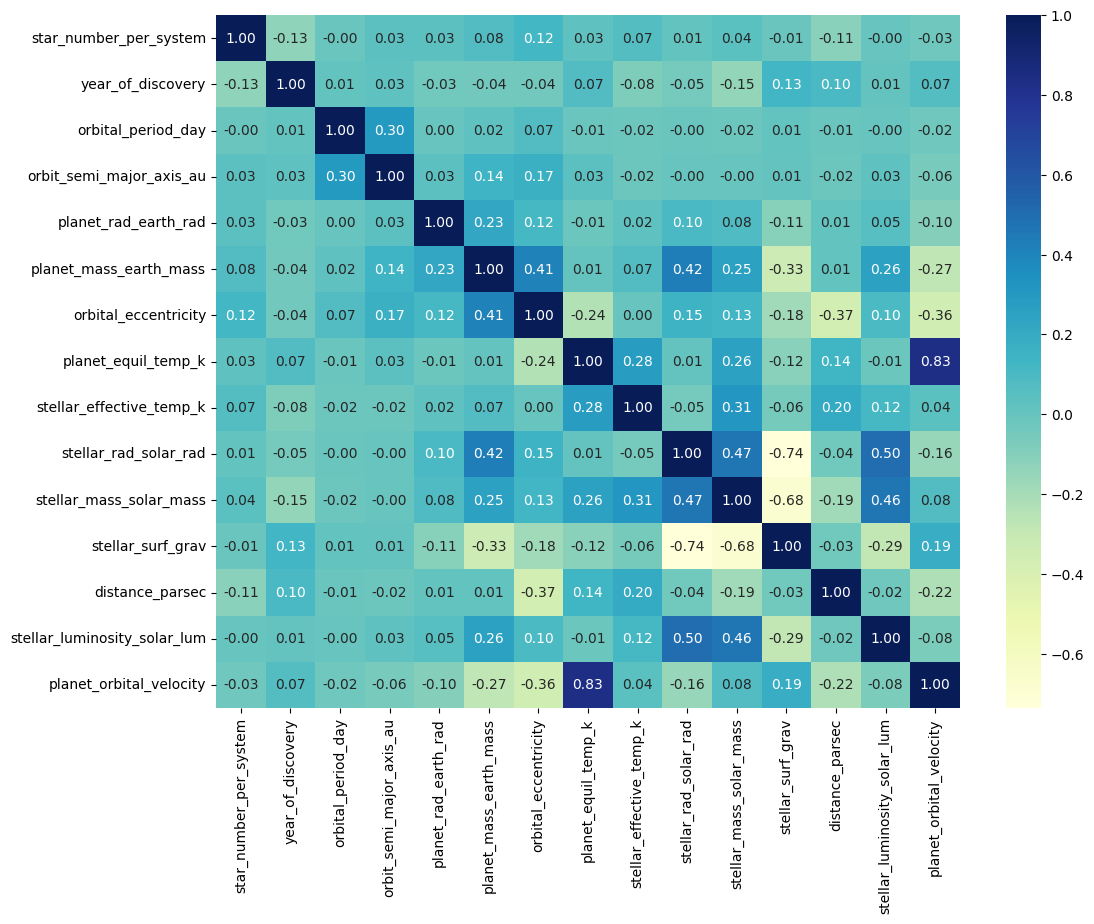

In [72]:
# checking for any correlations between the variables in the dataset
# creating a correlation heatmap
plt.figure(figsize=(12, 9))
correlation_matrix = new_exoplanets_filtered2.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt=".2f")

#### 4) What is the Distribution of Exoplanet Mass?

In [87]:
# viewing the total number of planets that are Earth Like in mass (1 <= Mp < 2)
earth_like_count = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_mass_earth_mass"] >= 1) &
 (new_exoplanets_filtered2["planet_mass_earth_mass"] < 2)])
print("Number of Earth-like planets:", earth_like_count)

# viewing the total number of planets that are Super-Earth Like in mass (2 <= Mp < 8)
super_earth_like_count = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_mass_earth_mass"] >= 2) &
 (new_exoplanets_filtered2["planet_mass_earth_mass"] < 8)])
print("Number of Super-Earth like planets:", super_earth_like_count)

# viewing the total number of planets that are Neptune Like in mass (8 <= Mp <= 80)
neptune_like_count = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_mass_earth_mass"] >= 8) &
 (new_exoplanets_filtered2["planet_mass_earth_mass"] <= 80)])
print("Number of Neptune like planets:", neptune_like_count)

# viewing the total number of planets that are Saturn Like in mass (80 < Mp <= 150)
saturn_like_count = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_mass_earth_mass"] > 80) &
 (new_exoplanets_filtered2["planet_mass_earth_mass"] <= 150)])
print("Number of Saturn like planets:", saturn_like_count)

# viewing the total number of planets that are Super-Saturn Like in mass (150 < Mp < 318)
super_saturn_like_count = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_mass_earth_mass"] > 150) &
 (new_exoplanets_filtered2["planet_mass_earth_mass"] < 318)])
print("Number of Super-Saturn like planets:", super_saturn_like_count)

# viewing the total number of planets that are Jupiter Like in mass (318 <= Mp <= 3180)
jupiter_like_count = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_mass_earth_mass"] >= 318) &
 (new_exoplanets_filtered2["planet_mass_earth_mass"] <= 3180)])
print("Number of Jupiter like planets:", jupiter_like_count)

# viewing the total number of planets that are Super-Jupiter Like in mass (Mp > 3180)
super_jupiter_like_count = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_mass_earth_mass"] > 3180)])
print("Number of Super-Jupiter like planets:", super_jupiter_like_count)

Number of Earth-like planets: 2510
Number of Super-Earth like planets: 696
Number of Neptune like planets: 799
Number of Saturn like planets: 207
Number of Super-Saturn like planets: 422
Number of Jupiter like planets: 1012
Number of Super-Jupiter like planets: 193


In [97]:
total_mass = earth_like_count + super_earth_like_count + neptune_like_count + saturn_like_count + super_saturn_like_count + jupiter_like_count + super_jupiter_like_count
total_mass

5839

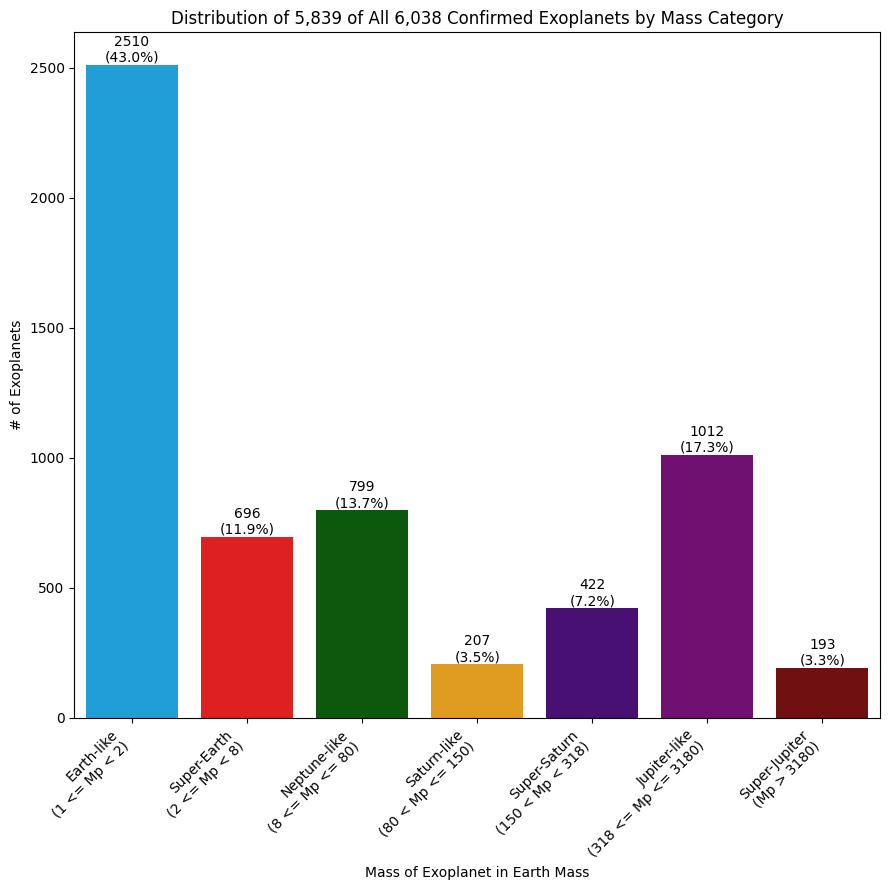

In [125]:
# Store categories and counts
categories = [
    "Earth-like\n(1 <= Mp < 2)",
    "Super-Earth\n(2 <= Mp < 8)",
    "Neptune-like\n(8 <= Mp <= 80)",
    "Saturn-like\n(80 < Mp <= 150)",
    "Super-Saturn\n(150 < Mp < 318)",
    "Jupiter-like\n(318 <= Mp <= 3180)",
    "Super-Jupiter\n(Mp > 3180)"
]

counts = [
    earth_like_count,
    super_earth_like_count,
    neptune_like_count,
    saturn_like_count,
    super_saturn_like_count,
    jupiter_like_count,
    super_jupiter_like_count
]

# Create DataFrame for plotting
planet_counts_df = pd.DataFrame({
    "Mass of Exoplanet in Earth Mass": categories,
    "# of Exoplanets": counts
})

plt.figure(figsize=(9, 9))
ax = sns.barplot(
    data=planet_counts_df,
    x="Mass of Exoplanet in Earth Mass",
    y="# of Exoplanets",
    palette=[
        "#03A9F4",   # Earth-like
        "red",   # Super-Earth
        "darkgreen",   # Neptune-like
        "orange",   # Saturn-like
        "indigo",   # Super-Saturn
        "purple",   # Jupiter-like
        "maroon"    # Super-Jupiter
    ]
)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of 5,839 of All 6,038 Confirmed Exoplanets by Mass Category")

# Add counts and percentages on tope of each bar
total = planet_counts_df["# of Exoplanets"].sum()

for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    percentage = (height / total) * 100

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### 5) What is the Distribution of Exoplanet Radius?

In [96]:
# viewing the total number of planets that are Earth Like in radius (Rp <= 1.5)
earth_like_count_rad = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_rad_earth_rad"] <= 1.5)])
print("Number of Earth-like planets:", earth_like_count_rad)

# viewing the total number of planets that are Super-Earth Like in radius (1.5 < Rp <= 2)
super_earth_like_count_rad = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_rad_earth_rad"] > 1.5) &
 (new_exoplanets_filtered2["planet_rad_earth_rad"] <= 2)])
print("Number of Super-Earth like planets:", super_earth_like_count_rad)

# viewing the total number of planets that are Neptune Like in radius (2 < Rp <= 6)
neptune_like_count_rad = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_rad_earth_rad"] > 2) &
 (new_exoplanets_filtered2["planet_rad_earth_rad"] <= 6)])
print("Number of Neptune like planets:", neptune_like_count_rad)

# viewing the total number of planets that are Saturn Like in radius (6 < Rp <= 9)
saturn_like_count_rad = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_rad_earth_rad"] > 6) &
 (new_exoplanets_filtered2["planet_rad_earth_rad"] <= 9)])
print("Number of Saturn like planets:", saturn_like_count_rad)

# viewing the total number of planets that are Super-Saturn Like in radius (9 < Rp <= 11)
super_saturn_like_count_rad = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_rad_earth_rad"] > 9) &
 (new_exoplanets_filtered2["planet_rad_earth_rad"] <= 11)])
print("Number of Super-Saturn like planets:", super_saturn_like_count_rad)

# viewing the total number of planets that are Jupiter Like in radius (11 < Rp <= 15)
jupiter_like_count_rad = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_rad_earth_rad"] > 11) &
 (new_exoplanets_filtered2["planet_rad_earth_rad"] <= 15)])
print("Number of Jupiter like planets:", jupiter_like_count_rad)

# viewing the total number of planets that are Super-Jupiter Like in radius (Rp > 15)
super_jupiter_like_count_rad = len(new_exoplanets_filtered2[(new_exoplanets_filtered2["planet_rad_earth_rad"] > 15)])
print("Number of Super-Jupiter like planets:", super_jupiter_like_count_rad)

Number of Earth-like planets: 940
Number of Super-Earth like planets: 748
Number of Neptune like planets: 2306
Number of Saturn like planets: 221
Number of Super-Saturn like planets: 211
Number of Jupiter like planets: 580
Number of Super-Jupiter like planets: 1032


In [99]:
total_rad = earth_like_count_rad + super_earth_like_count_rad + neptune_like_count_rad + saturn_like_count_rad + super_saturn_like_count_rad + jupiter_like_count_rad + super_jupiter_like_count_rad
total_rad

6038

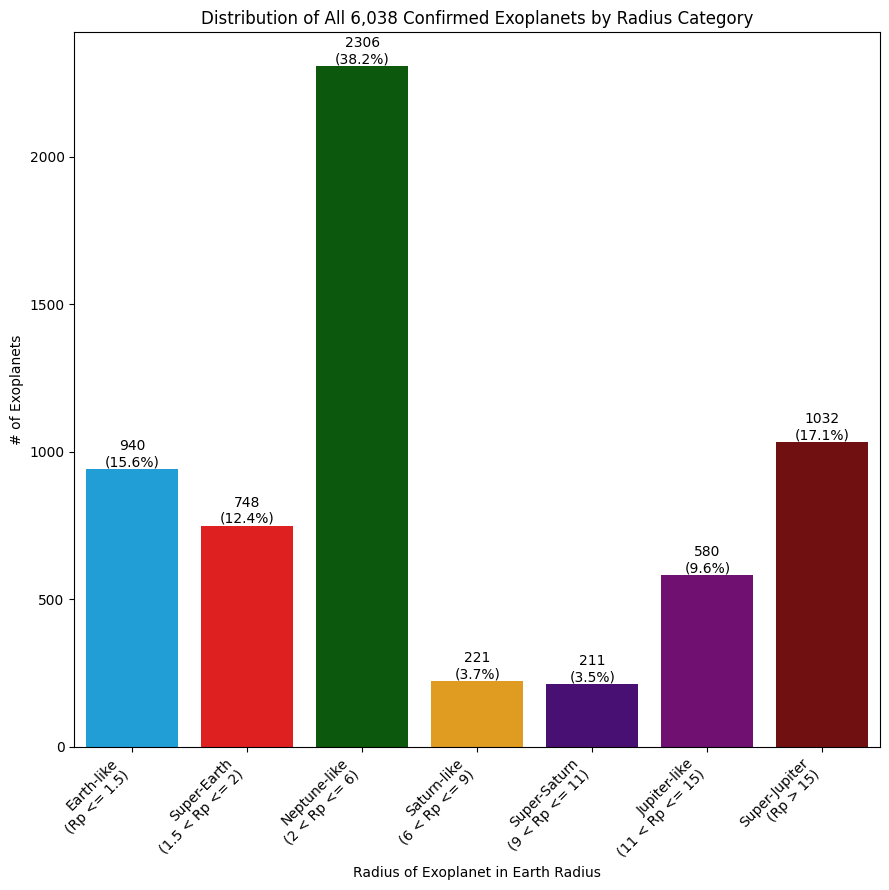

In [152]:
# Store categories and counts
categories = [
    "Earth-like\n(Rp <= 1.5)",
    "Super-Earth\n(1.5 < Rp <= 2)",
    "Neptune-like\n(2 < Rp <= 6)",
    "Saturn-like\n(6 < Rp <= 9)",
    "Super-Saturn\n(9 < Rp <= 11)",
    "Jupiter-like\n(11 < Rp <= 15)",
    "Super-Jupiter\n(Rp > 15)"
]

counts = [
    earth_like_count_rad,
    super_earth_like_count_rad,
    neptune_like_count_rad,
    saturn_like_count_rad,
    super_saturn_like_count_rad,
    jupiter_like_count_rad,
    super_jupiter_like_count_rad
]

# Create DataFrame for plotting
planet_counts_df = pd.DataFrame({
    "Radius of Exoplanet in Earth Radius": categories,
    "# of Exoplanets": counts
})

plt.figure(figsize=(9, 9))
ax = sns.barplot(
    data=planet_counts_df,
    x="Radius of Exoplanet in Earth Radius",
    y="# of Exoplanets",
    palette=[
        "#03A9F4",   # Earth-like
        "red",   # Super-Earth
        "darkgreen",   # Neptune-like
        "orange",   # Saturn-like
        "indigo",   # Super-Saturn
        "purple",   # Jupiter-like
        "maroon"    # Super-Jupiter
    ]
)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of All 6,038 Confirmed Exoplanets by Radius Category")

# Add counts and percentages on tope of each bar
total = planet_counts_df["# of Exoplanets"].sum()

for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    percentage = (height / total) * 100

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### 6) What is the Distribution of Exoplanet Orbital Period in Earth Days?

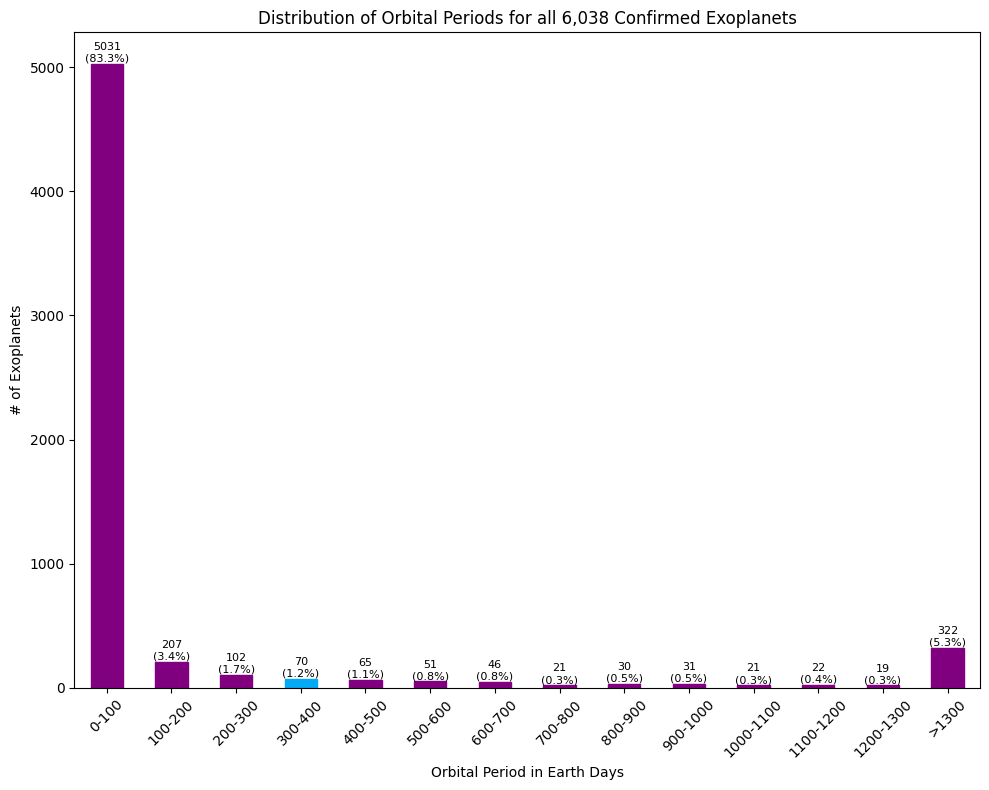

In [145]:
bins = list(range(0, 1400, 100))
bins.append(float("inf"))

labels = [f"{i}-{i+100}" for i in range(0, 1300, 100)]
labels.append(">1300")

new_exoplanets_filtered2["period_bin"] = pd.cut(
    new_exoplanets_filtered2["orbital_period_day"],
    bins=bins,
    labels=labels,
    right=False
)

period_counts = new_exoplanets_filtered2["period_bin"].value_counts().sort_index()

# Create color list (default purple)
colors = ["purple"] * len(period_counts)

# Find index of the 300-400 bin
highlight_index = period_counts.index.get_loc("300-400")

# Change that one to blue
colors[highlight_index] = "#03A9F4"

plt.figure(figsize=(10, 8))

period_counts.plot(
    kind="bar",
    color=colors,
    edgecolor=colors
)

plt.xlabel("Orbital Period in Earth Days")
plt.ylabel("# of Exoplanets")
plt.title("Distribution of Orbital Periods for all 6,038 Confirmed Exoplanets")

# Add labels
total = period_counts.sum()
ax = plt.gca()

for bar in ax.patches:
    height = bar.get_height()
    percentage = (height / total) * 100

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [131]:
period_counts = new_exoplanets_filtered2["period_bin"].value_counts().sort_index()
period_counts

,count
period_bin,
0-100,5031
100-200,207
200-300,102
300-400,70
400-500,65
500-600,51
600-700,46
700-800,21
800-900,30


#### 7) What is the Distribution of Distance between Exoplanet and its Host Star in AU?

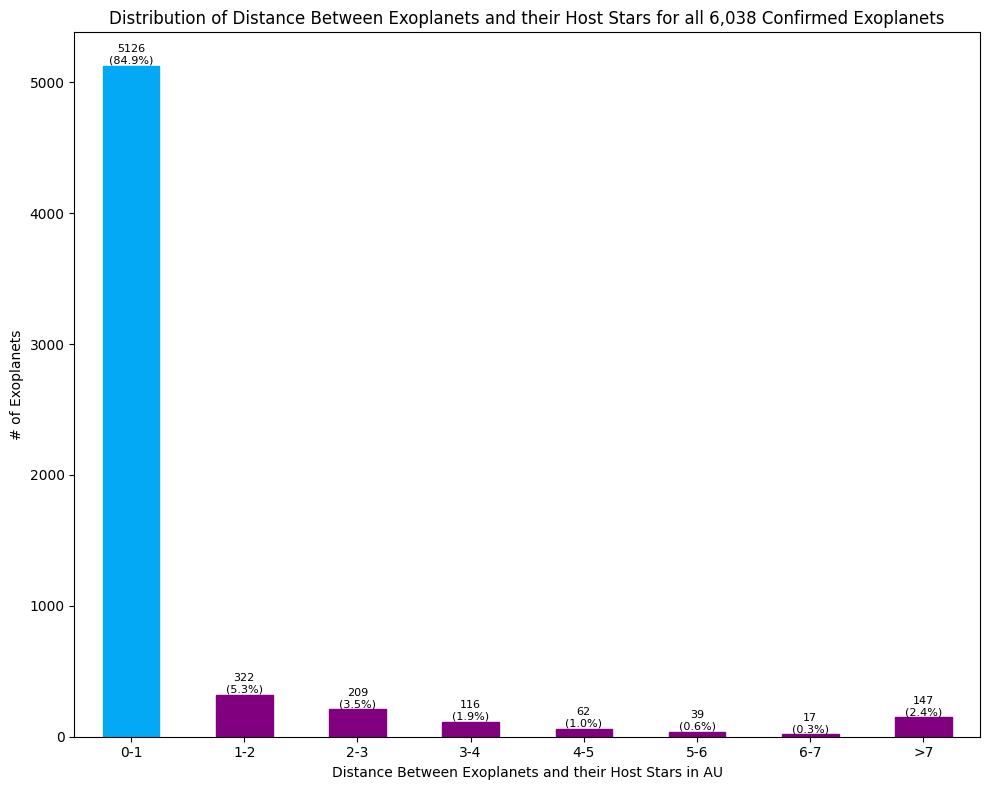

In [146]:
bins = list(range(0, 8, 1))
bins.append(float("inf"))

labels = [f"{i}-{i+1}" for i in range(0, 7, 1)]
labels.append(">7")

new_exoplanets_filtered2["distance_bin"] = pd.cut(
    new_exoplanets_filtered2["orbit_semi_major_axis_au"],
    bins=bins,
    labels=labels,
    right=False
)

distance_counts = new_exoplanets_filtered2["distance_bin"].value_counts().sort_index()

# Create color list (default purple)
colors = ["purple"] * len(distance_counts)

# Find index of the 0-1 bin
highlight_index = distance_counts.index.get_loc("0-1")

# Change that one to blue
colors[highlight_index] = "#03A9F4"

plt.figure(figsize=(10, 8))

distance_counts.plot(
    kind="bar",
    color=colors,
    edgecolor=colors
)

plt.xlabel("Distance Between Exoplanets and their Host Stars in AU")
plt.ylabel("# of Exoplanets")
plt.title("Distribution of Distance Between Exoplanets and their Host Stars for all 6,038 Confirmed Exoplanets")

# Add labels
total = distance_counts.sum()
ax = plt.gca()

for bar in ax.patches:
    height = bar.get_height()
    percentage = (height / total) * 100

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [137]:
distance_counts = new_exoplanets_filtered2["distance_bin"].value_counts().sort_index()
distance_counts

,count
distance_bin,
0-1,5126
1-2,322
2-3,209
3-4,116
4-5,62
5-6,39
6-7,17
>7,147


#### 8) What is the Distribution of Discovery Methods?

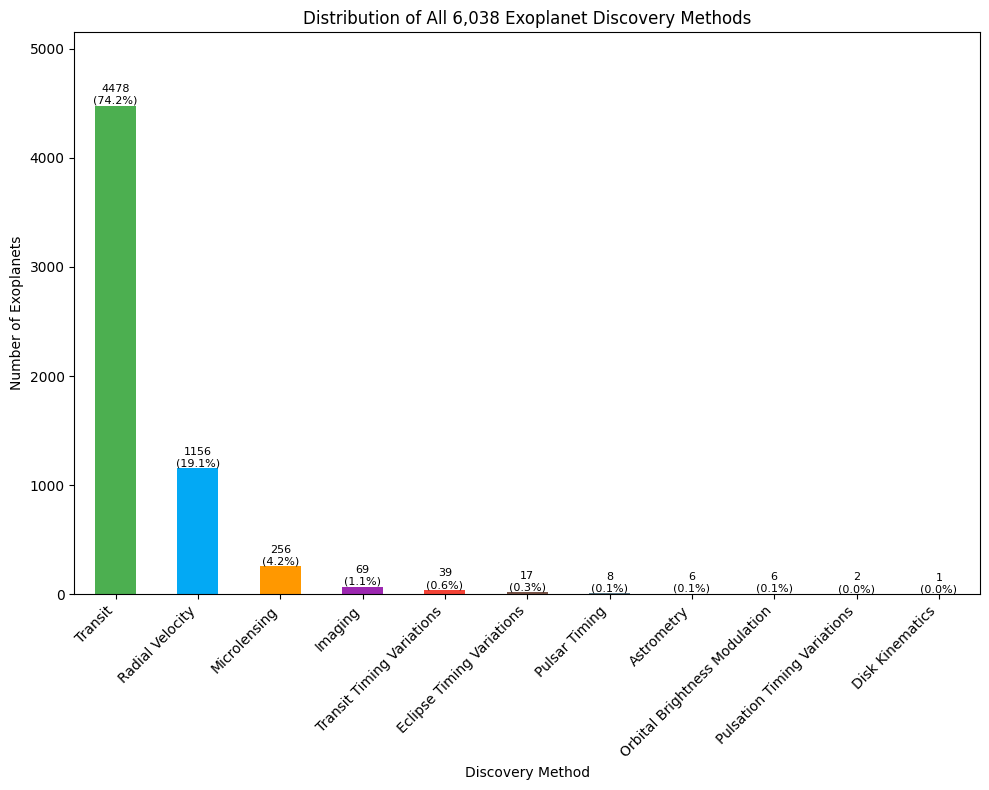

In [157]:
plt.figure(figsize=(10, 8))

method_counts = new_exoplanets_filtered2['discovery_method'].value_counts()

method_counts.plot(
    kind='bar',
    color = [
    "#4CAF50",   # Transit
    "#03A9F4",   # Radial Velocity
    "#FF9800",   # Microlensing
    "#9C27B0",   # Imaging
    "#F44336",   # Transit Timing Variations
    "#795548",   # Astrometry
    "#607D8B"    # Other (if present)
]
)

plt.xlabel("Discovery Method")
plt.ylabel("Number of Exoplanets")
plt.title("Distribution of All 6,038 Exoplanet Discovery Methods")

# Add labels
total = method_counts.sum()
ax = plt.gca()

for bar in ax.patches:
    height = bar.get_height()
    percentage = (height / total) * 100

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(method_counts) * 1.15)
plt.tight_layout()
plt.show()

#### 9) What is the Distribution of Discovery Years?

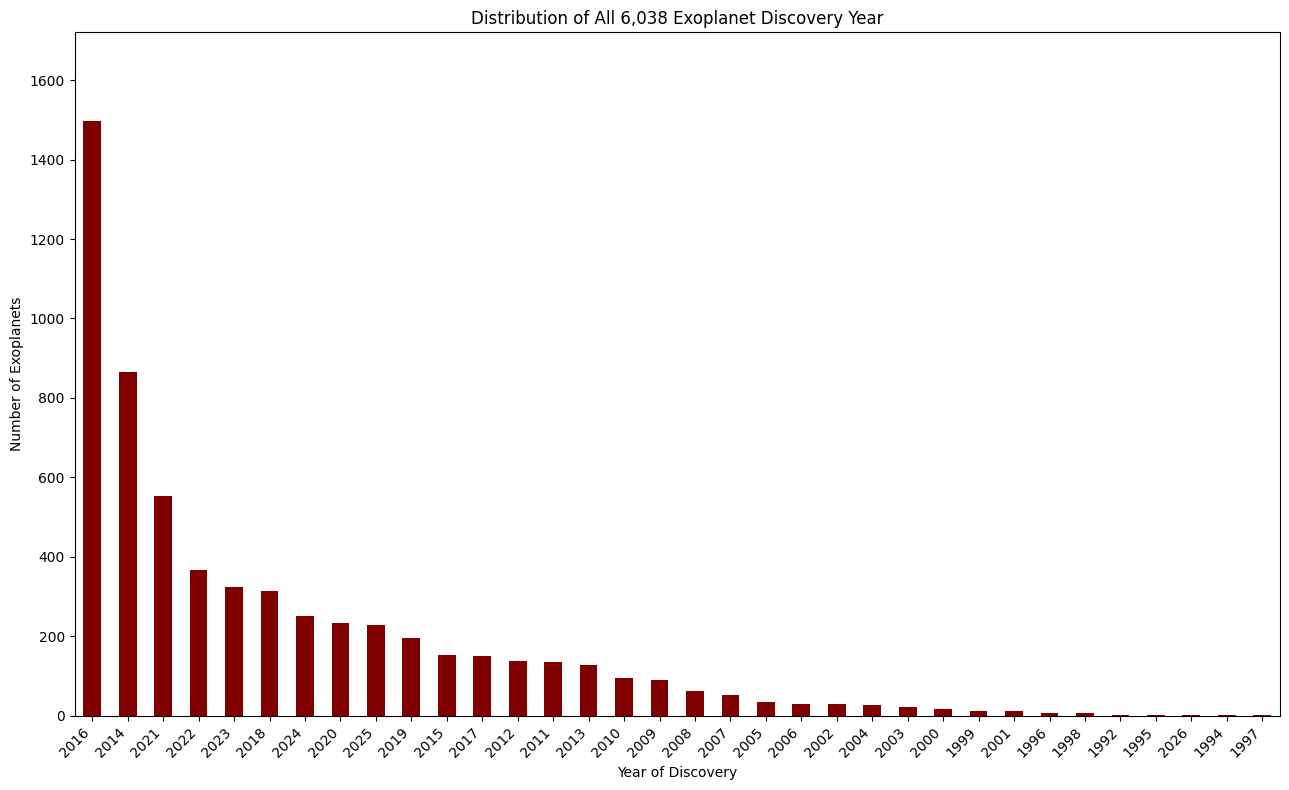

In [164]:
new_exoplanets_filtered2['year_of_discovery'] = (new_exoplanets_filtered2['year_of_discovery'].astype(int))

plt.figure(figsize=(13, 8))

year_counts = new_exoplanets_filtered2['year_of_discovery'].value_counts()

year_counts.plot(
    kind='bar',
    color = 'maroon'
)

plt.xlabel("Year of Discovery")
plt.ylabel("Number of Exoplanets")
plt.title("Distribution of All 6,038 Exoplanet Discovery Year")

plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(year_counts) * 1.15)
plt.tight_layout()
plt.show()